
<div id="haut2page" style="border:3px solid black; padding:3%; font-size:314% ; text-align:center; color:white; background-color:black;">
    Diagnostic de Performance Énergétique des Bâtiments 

</div>



# Contexte du projet 

Présenter le contexte du projet, introduire le jeu de données utilisé, définir les objectifs de l’analyse, détailler les principales étapes de l’étude ainsi que les résultats attendus, tout en rappelant brièvement les méthodes mobilisées et en facilitant la navigation entre les différentes parties.

Ce projet s’inscrit dans le cadre d’un défi proposé par Open Data University, en partenariat avec Enedis, autour des diagnostics de performance énergétique des bâtiments. L’objectif est notamment de mieux comprendre l’impact des caractéristiques des logements et des travaux de rénovation sur leur consommation énergétique, dans un contexte de transition énergétique et de lutte contre le changement climatique.

Le jeu de données utilisé résulte d’un travail de fusion entre les données de DPE et les données réelles de consommation énergétique. Il regroupe ainsi des informations variées sur les bâtiments, incluant des éléments de localisation, des caractéristiques physiques (surface, année de construction, nombre de niveaux), ainsi que des données techniques liées aux systèmes de chauffage, à l’eau chaude sanitaire et à l’isolation.

On y retrouve également de nombreux indicateurs énergétiques, comme les consommations par usage, les émissions de gaz à effet de serre ou encore les coûts associés. Certaines variables permettent aussi d’analyser plus finement les performances thermiques du bâtiment, notamment à travers les déperditions ou la qualité de l’isolation.

Dans ce contexte, ce jeu de données constitue un support particulièrement pertinent pour étudier les écarts de performance énergétique entre les bâtiments, identifier les logements les plus énergivores (notamment les passoires thermiques classées F ou G), et mieux comprendre les leviers d’amélioration liés à la rénovation énergétique.

Enfin, une étape de clustering sera mise en place afin de regrouper les bâtiments selon leurs caractéristiques énergétiques. L’objectif sera de faire émerger des profils types de logements, d’identifier des comportements similaires et d’apporter une lecture complémentaire des données à travers ces regroupements.

## Sommaire

- [Contexte du projet](#contexte-du-projet)
- [Importation des bibliothèques nécessaires](#importation-des-bibliothèques-nécessaires)
- [Lecture des données](#lecture-des-données)
- [Nettoyage des données](#nettoyage)
- [Analyse exploratoire des données](#analyse-exploratoire-des-données)
- [Fusion de df_quant et df_qual](#fusion-de-df_quant-et-df_qual)
- [Création de fonctions](#création-de-fonctions)
- [Normalisation et matrice de corrélation](#normalisation-et-matrice-de-corrélation)
- [Réduction de dimension par régression linéaire simple](#réduction-de-dimension-par-régression-linéaire-simple)
- [Comparaison de deux ACP](#comparaison-de-deux-acp)
- [Bilan ACP](#bilan-acp)
- [Mise en place du clustering](#mise-en-place-du-clustering)
- [Détermination du nombre de clusters et mise en place du K-Means](#détermination-du-nombre-de-clusters-et-mise-en-place-du-k-means)
- [Suppression des outliers avec la méthode IQR](#suppression-des-outliers-avec-la-méthode-iqr)
- [Prédiction DPE avec Random Forest](#prédiction-dpe-avec-random-forest)
- [Conclusion](#conclusion)

# Importation des bibliothèques nécessaires

Les bibliothèques suivantes sont importées afin de permettre le bon déroulement de l’analyse et l’utilisation des différentes méthodes statistiques et de visualisation.

In [23]:
import pandas as pd  # gestion et manipulation des données sous forme de DataFrame
import numpy as np   # opérations numériques et calculs matriciels

from scipy.stats import t, f  # distributions statistiques (Student, Fisher)

import matplotlib.pyplot as plt  # création de graphiques
import seaborn as sns            # visualisations avancées

from tqdm import tqdm  # affichage d’une barre de progression lors des boucles

from sklearn.model_selection import train_test_split  # séparation des données
from sklearn.ensemble import RandomForestClassifier   # modèle de classification
from sklearn.metrics import classification_report, accuracy_score  # évaluation des performances
from sklearn.cluster import KMeans  # algorithme de clustering
from sklearn.tree import plot_tree  # visualisation d’arbres de décision

import warnings  # gestion des messages d’avertissement
warnings.filterwarnings("ignore")  # désactivation des warnings pour plus de lisibilité

# Lecture des Données 

Les données sont importées à l’aide de la bibliothèque pandas. Une copie du jeu de données est ensuite créée afin de préserver les données originales et éviter toute modification directe.

In [116]:
data = pd.read_csv("DATA.csv", low_memory=False)  # chargement du fichier
df = data.copy()  # création d'une copie de travail
df.head()  # aperçu des premières lignes

,N°DPE,Date_réception_DPE,Date_établissement_DPE,Date_visite_diagnostiqueur,Modèle_DPE,N°_DPE_remplacé,Date_fin_validité_DPE,Version_DPE,N°_DPE_immeuble_associé,Appartement_non_visité_(0/1),Méthode_application_DPE,N°_immatriculation_copropriété,Invariant_fiscal_logement,N°_RPLS_logement,Etiquette_GES,Etiquette_DPE,Année_construction,Type_bâtiment,Type_installation_chauffage,Type_installation_ECS_(général),Période_construction,Hauteur_sous-plafond,Nombre_appartement,Nombre_niveau_immeuble,Nombre_niveau_logement,Surface_habitable_immeuble,Surface_habitable_logement,Surface_tertiaire_immeuble,Classe_inertie_bâtiment,Typologie_logement,Position_logement_dans_immeuble,Classe_altitude,Zone_climatique_,Adresse_brute,Nom__commune_(BAN),Code_INSEE_(BAN),N°_voie_(BAN),Identifiant__BAN,Adresse_(BAN),Code_postal_(BAN),Score_BAN,Nom__rue_(BAN),Coordonnée_cartographique_X_(BAN),Coordonnée_cartographique_Y_(BAN),Code_postal_(brut),N°_étage_appartement,Nom_résidence,Complément_d'adresse_bâtiment,Cage_d'escalier,Complément_d'adresse_logement,Statut_géocodage,N°_département_(BAN),N°_région_(BAN),Conso_5_usages_é_finale,Conso_5_usages/m²_é_finale,Conso_chauffage_é_finale,Conso_chauffage_dépensier_é_finale,Conso_éclairage_é_finale,Conso_ECS_é_finale,Conso_ECS_dépensier_é_finale,Conso_refroidissement_é_finale,Conso_refroidissement_dépensier_é_finale,Conso_auxiliaires_é_finale,Conso_5_usages_é_primaire,Conso_5_usages_par_m²_é_primaire,Conso_chauffage_é_primaire,Conso_chauffage_dépensier_é_primaire,Conso_éclairage_é_primaire,Conso_ECS_é_primaire,Conso_ECS_dépensier_é_primaire,Conso_refroidissement_é_primaire,Conso_refroidissement_dépensier_é_primaire,Conso_auxiliaires_é_primaire,Emission_GES_5_usages,Emission_GES_5_usages_par_m²,Emission_GES_chauffage,Emission_GES_chauffage_dépensier,Emission_GES_éclairage,Emission_GES_ECS,Emission_GES_ECS_dépensier,Emission_GES_refroidissement,Emission_GES_refroidissement_dépensier,Emission_GES_auxiliaires,Conso_5_usages_é_finale_énergie_n°1,Conso_chauffage_é_finale_énergie_n°1,Conso_ECS_é_finale_énergie_n°1,Coût_total_5_usages_énergie_n°1,Coût_chauffage_énergie_n°1,Coût_ECS_énergie_n°1,Emission_GES_5_usages_énergie_n°1,Emission_GES_chauffage_énergie_n°1,Emission_GES_ECS_énergie_n°1,Type_énergie_n°1,Conso_5_usages_é_finale_énergie_n°2,Conso_chauffage_é_finale_énergie_n°2,Conso_ECS_é_finale_énergie_n°2,Coût_total_5_usages_énergie_n°2,Coût_chauffage_énergie_n°2,Coût_ECS_énergie_n°2,Emission_GES_5_usages_énergie_n°2,Emission_GES_chauffage_énergie_n°2,Emission_GES_ECS_énergie_n°2,Type_énergie_n°2,Conso_5_usages_é_finale_énergie_n°3,Conso_chauffage_é_finale_énergie_n°3,Conso_ECS_é_finale_énergie_n°3,Coût_total_5_usages_énergie_n°3,Coût_chauffage_énergie_n°3,Coût_ECS_énergie_n°3,Emission_GES_5_usages_énergie_n°3,Emission_GES_chauffage_énergie_n°3,Emission_GES_ECS_énergie_n°3,Type_énergie_n°3,Coût_total_5_usages,Coût_chauffage,Coût_chauffage_dépensier,Coût_éclairage,Coût_ECS,Coût_ECS_dépensier,Coût_refroidissement,Coût_refroidissement_dépensier,Coût_auxiliaires,Logement_traversant_(0/1),Présence_brasseur_air_(0/1),Indicateur_confort_été,Isolation_toiture_(0/1),Protection_solaire_exterieure_(0/1),Inertie_lourde_(0/1),Deperditions_baies_vitrées,Deperditions_enveloppe,Déperditions_murs,Deperditions_planchers_bas,Deperditions_planchers_hauts,Déperditions_ponts_thermiques,Déperditions_portes,Déperditions_renouvellement_air,Qualité_isolation_enveloppe,Qualité_isolation_menuiseries,Qualité_isolation_murs,Qualité_isolation_plancher_bas,Ubat_W/m²_K,Qualité_isolation_plancher_haut_toit_terrase,Qualité_isolation_plancher_haut_comble_aménagé,Qualité_isolation_plancher_haut_comble_perdu,Apports_internes_saison_chauffe_,Apports_internes_saison_froid,Apports_solaires_saison_chauffe,Apports_solaires_saison_froid,Besoin_chauffage,Besoin_ECS,Besoin_refroidissement,Besoin_refroidissement_dépensier,Type_énergie_principale_chauffage,Conso_chauffage_installation_chauffage_n°1,Conso_chauffage_dépensier_installation_chauffage_n°1,Description_ins

In [117]:
print(f"Le jeu de données contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

Le jeu de données contient 8718 lignes et 242 colonnes.


Avant toute modélisation, une phase de préparation des données est donc nécessaire afin d’identifier les variables exploitables et de garantir la qualité des analyses qui seront menées par la suite.

# Nettoyage des données <a id="nettoyage"></a>

Afin d’évaluer la qualité du jeu de données, nous commençons par mesurer le nombre de valeurs manquantes
présentes dans chaque variable. Cette étape permet d’identifier les colonnes les plus incomplètes et de
préparer une stratégie de nettoyage cohérente avec l’objectif de l’analyse.

In [118]:
# nombre de colonne par type de données 
df.dtypes.value_counts()

float64    153
object      88
int64        1
Name: count, dtype: int64

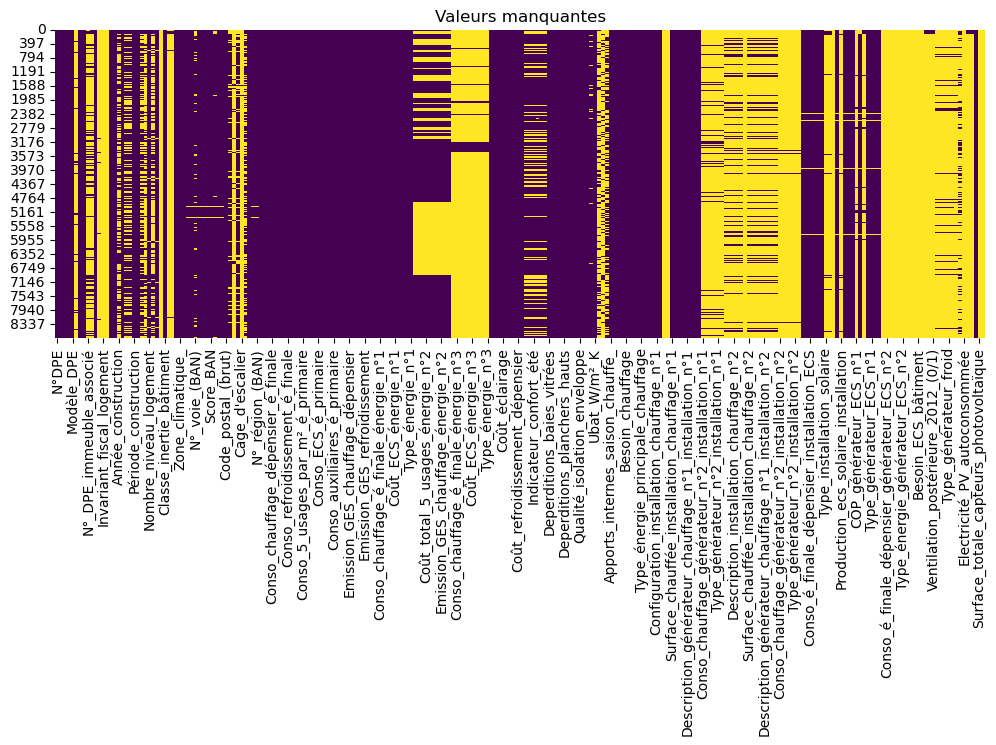

In [119]:
# visualisation des valeurs manquantes
plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Valeurs manquantes")
plt.show()

L’analyse des types de variables montre que le jeu de données est majoritairement composé de variables numériques, avec 153 variables de type float, contre 88 variables de type object et une seule variable entière. Cela confirme que la base est particulièrement riche en informations quantitatives, ce qui est adapté pour des analyses statistiques comme la régression ou l’ACP.

La visualisation des valeurs manquantes à l’aide de la heatmap met en évidence une forte hétérogénéité dans la qualité des données. Certaines variables sont presque entièrement renseignées, tandis que d’autres présentent une proportion très importante de valeurs manquantes, voire sont presque vides. Cette situation peut s’expliquer par la présence de variables très spécifiques, liées à certains types d’installations ou de configurations de bâtiments.

Ainsi, la prochaine étape consiste à quantifier précisément le nombre et la proportion de valeurs manquantes pour chaque variable, afin d’identifier les colonnes les moins exploitables et de décider des suppressions nécessaires pour garantir la qualité de l’analyse.

In [120]:
(df.isna().sum()/df.shape[0]).sort_values(ascending = False).round(2).value_counts()

0.00    127
1.00     27
0.80     13
0.95     11
0.38     10
0.99      7
0.26      6
0.90      6
0.92      5
0.94      3
0.97      3
0.03      2
0.98      2
0.31      2
0.77      2
0.05      1
0.11      1
0.02      1
0.12      1
0.16      1
0.01      1
0.54      1
0.37      1
0.40      1
0.47      1
0.72      1
0.73      1
0.74      1
0.83      1
0.93      1
0.60      1
Name: count, dtype: int64

La distribution des valeurs manquantes montre que 127 variables sont entièrement complètes, ce qui constitue un point positif pour l’analyse. En revanche, 27 variables sont totalement vides et ne contiennent aucune information exploitable.

On observe également qu’un nombre important de variables présente un taux de valeurs manquantes très élevé (souvent supérieur à 80 % ou 90 %). Cela indique que certaines informations ne sont disponibles que pour une petite partie des observations, ce qui limite fortement leur utilisation dans une analyse globale.

Ainsi, cette répartition confirme la nécessité d’un travail de sélection des variables. Les colonnes trop incomplètes devront être supprimées, tandis que les variables suffisamment renseignées pourront être conservées pour la suite de l’analyse.

In [121]:
# On garde uniquement les colonnes avec moins de 80% de valeurs manquates pour le moment 
df = df[df.columns[(df.isna().sum() / df.shape[0]).round(2) < 0.8]]
df.shape

(8718, 163)

Après cette première étape de tri, il reste 163 variables. À ce stade, il est encore nécessaire de visualiser les valeurs manquantes afin de vérifier si certaines colonnes restent trop incomplètes pour être conservées.

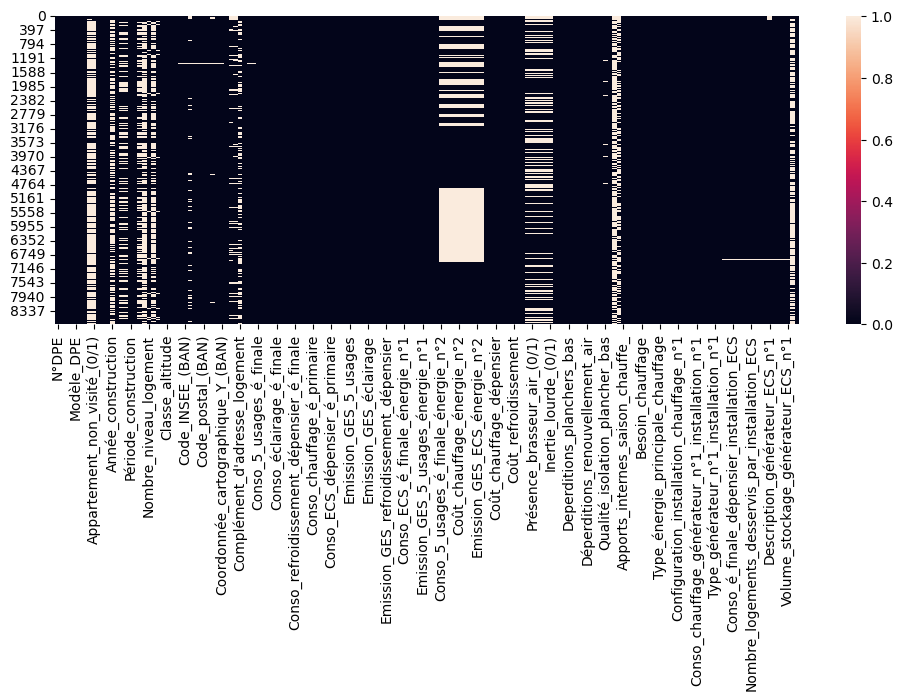

In [122]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull())
plt.show()

À ce stade, On remarque  encore la présence de nombreuses valeurs manquantes, bien que certaines variables aient été conservées. Afin de poursuivre le nettoyage de manière structurée, deux approches seront adoptées : dans un premier temps, un travail sera réalisé sur les variables quantitatives, puis dans un second temps sur les variables qualitatives.

In [123]:
df_quant = df.select_dtypes(include=['number'])  # variables quantitatives
df_qual = df.select_dtypes(exclude=['number'])   # variables qualitatives

In [124]:
df_quant.shape

(8718, 106)

In [125]:
df_qual.shape

(8718, 57)

**Traitement des variables quantitatifs**

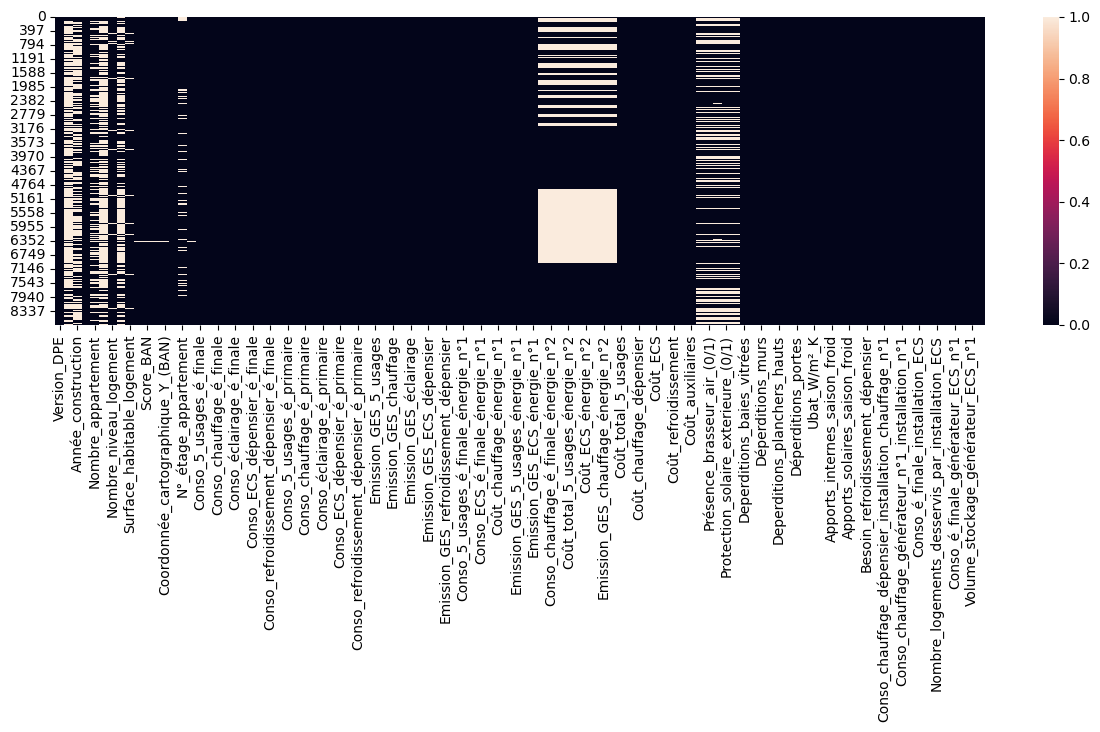

In [126]:
plt.figure(figsize=(15, 4))
sns.heatmap(df_quant.isnull())
plt.show()

In [127]:
# nombre de colonne vide par pourcentage
(df_quant.isna().sum()/df.shape[0]).round(2).value_counts().sort_index()

0.00    84
0.03     2
0.11     1
0.26     5
0.37     1
0.38     9
0.54     1
0.60     1
0.74     1
0.77     1
Name: count, dtype: int64

L’analyse des variables quantitatives montre que la majorité d’entre elles sont bien renseignées, avec 84 variables ne contenant aucune valeur manquante. Quelques variables présentent un faible taux de valeurs manquantes, tandis que d’autres restent plus incomplètes, mais dans des proportions globalement limitées.

Cela indique que les variables quantitatives sont globalement exploitables pour la suite de l’analyse, avec éventuellement un traitement des valeurs manquantes pour certaines d’entre elles.

In [128]:
pd.set_option('display.max_columns', None)
df_quant[df_quant.columns[(df_quant.isna().sum() / df_quant.shape[0]) > 0]].describe()

,Appartement_non_visité_(0/1),Année_construction,Nombre_appartement,Nombre_niveau_immeuble,Nombre_niveau_logement,Surface_habitable_immeuble,Surface_habitable_logement,Code_postal_(BAN),Score_BAN,Coordonnée_cartographique_X_(BAN),Coordonnée_cartographique_Y_(BAN),N°_étage_appartement,N°_région_(BAN),Conso_5_usages_é_finale_énergie_n°2,Conso_chauffage_é_finale_énergie_n°2,Conso_ECS_é_finale_énergie_n°2,Coût_total_5_usages_énergie_n°2,Coût_chauffage_énergie_n°2,Coût_ECS_énergie_n°2,Emission_GES_5_usages_énergie_n°2,Emission_GES_chauffage_énergie_n°2,Emission_GES_ECS_énergie_n°2,Logement_traversant_(0/1),Présence_brasseur_air_(0/1),Isolation_toiture_(0/1),Protection_solaire_exterieure_(0/1),Inertie_lourde_(0/1),Conso_é_finale_installation_ECS,Conso_é_finale_dépensier_installation_ECS,Nombre_logements_desservis_par_installation_ECS,Surface_habitable_desservie_par_installation_ECS,Conso_é_finale_générateur_ECS_n°1,Conso_é_finale_dépensier_générateur_ECS_n°1,Volume_stockage_générateur_ECS_n°1
count,2047.000000,3968.000000,5458.000000,2297.000000,8458.000000,3495.000000,8458.000000,8678.000000,8678.000000,8.678000e+03,8.678000e+03,7722.000000,8677.000000,5423.000000,5423.000000,5423.000000,5423.000000,5423.000000,5423.000000,5423.000000,5423.000000,5423.000000,6465.000000,6465.000000,6427.000000,6465.000000,6465.000000,8703.000000,8703.000000,8703.000000,8703.000000,8703.000000,8703.000000,8703.000000
mean,0.766976,1970.808468,21.607365,5.138006,1.324308,3157.566180,70.094159,55318.151648,0.671406,6.616685e+05,6.690632e+06,0.132349,47.312666,2189.234298,999.430371,507.576139,409.599982,99.723216,108.061110,178.300738,72.179569,61.911912,0.635112,0.055684,0.554847,0.565971,0.303016,13017.508779,18070.840285,1.155406,471.353189,13017.508779,18070.840250,140.149684
std,0.422861,38.432864,39.822972,2.655221,0.747502,6136.264916,41.635554,26140.547889,0.168457,1.966700e+05,2.449073e+05,0.700504,28.168557,6442.821612,4016.860677,4107.130630,1285.482763,570.771693,810.107604,1064.626626,643.091729,787.872526,0.481436,0.229329,0.497021,0.495667,0.459598,38403.650537,53953.716023,3.701106,1033.483054,38403.650537,53953.716033,262.259565
min,0.000000,1600.000000,1.000000,1.000000,1.000000,1.000000,8.900000,1000.000000,0.180000,1.265442e+05,6.103259e+06,-1.000000,6.000000,39.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,78.600000,110.900000,1.000000,8.900000,78.600000,110.900000,0.000000
25%,1.000000,1954.000000,1.000000,3.000000,1.000000,906.800000,43.000000,33820.000000,0.550000,5.354885e+05,6.496901e+06,0.000000,27.000000,413.800000,0.000000,0.000000,124.300000,0.000000,0.000000,25.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1506.800000,1967.950000,1.000000,51.700000,1506.800000,1967.950000,0.000000
50%,1.000000,1973.000000,1.000000,5.000000,1.000000,1991.000000,64.000000,59243.000000,0.650000,6.523662e+05,6.757071e+06,0.000000,44.000000,675.900000,0.000000,0.000000,184.800000,0.000000,0.000000,42.100000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1853.400000,2412.200000,1.000000,81.000000,1853.400000,2412.200000,80.000000
75%,1.000000,1998.000000,29.000000,5.000000,1.000000,3391.000000,86.375000,76120.000000,0.760000,8.207868e+05,6.866527e+06,0.000000,76.000000,1973.200000,0.000000,0.000000,343.900000,0.000000,0.000000,116.050000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2303.900000,2979.150000,1.000000,174.400000,2303.900000,2979.150000,200.000000
max,1.000000,2024.000000,1490.000000,13.000000,17.000000,148647.000000,618.000000,97640.000000,0.990000,1.240072e+06,8.579820e+06,13.000000,94.000000,233406.500000,105062.500000,233406.500000,38535.600000,20155.300000,35869.200000,52983.300000,23849.200000,52983.300000,1.000000,1.000000,1.000000,1.000000,1.000000,317089.400000,433792.000000,316.000000,5885.000000,317089.400000,433792.000000,5000.000000


In [129]:
pro_nan_quant = (df_quant.isna().sum() / df_quant.shape[0]) * 100

# Afficher seulement les variables avec des valeurs manquantes
pro_nan_quant[pro_nan_quant > 0].sort_values(ascending=False)

Appartement_non_visité_(0/1)                        76.519844
Nombre_niveau_immeuble                              73.652214
Surface_habitable_immeuble                          59.910530
Année_construction                                  54.484974
Conso_5_usages_é_finale_énergie_n°2                 37.795366
Emission_GES_ECS_énergie_n°2                        37.795366
Emission_GES_chauffage_énergie_n°2                  37.795366
Emission_GES_5_usages_énergie_n°2                   37.795366
Coût_ECS_énergie_n°2                                37.795366
Coût_total_5_usages_énergie_n°2                     37.795366
Conso_ECS_é_finale_énergie_n°2                      37.795366
Conso_chauffage_é_finale_énergie_n°2                37.795366
Coût_chauffage_énergie_n°2                          37.795366
Nombre_appartement                                  37.393898
Isolation_toiture_(0/1)                             26.278963
Présence_brasseur_air_(0/1)                         25.843083
Logement

On constate que plusieurs variables présentent des valeurs manquantes importantes, avec des distributions parfois très dispersées et la présence de valeurs extrêmes.

Nous choisissons de supprimer certaines variables liées à la localisation, car elles n’apportent pas d’information pertinente pour l’analyse énergétique :

- `Code_postal_(BAN)` : code postal issu de la base adresse nationale  
- `Score_BAN` : score de correspondance d’adresse  
- `Coordonnée_cartographique_X_(BAN)` et `Coordonnée_cartographique_Y_(BAN)` : coordonnées géographiques  
- `N°région(BAN)` : identifiant de région  

De plus, certaines variables sont retirées en raison d’un trop grand nombre de valeurs manquantes :

- `Appartement_non_visité_(0/1)` (76 %)  
- `Nombre_niveau_immeuble` (73 %)  
- `Surface_habitable_immeuble` (60 %)  
- `Année_construction` (54 %)  

La variable `Année_construction` reste cependant intéressante dans notre étude. Nous choisissons donc de la remplacer par la variable `Période_construction`, qui apporte une information similaire mais mieux renseignée.

Pour les autres variables contenant des valeurs manquantes, nous procédons à une imputation. Les variables quantitatives sont imputées par la médiane, car les distributions sont très dispersées et contiennent des valeurs extrêmes. Comme on peut le constater dans le résumé statistique, la moyenne est souvent supérieure à la médiane, ce qui traduit la présence d’outliers. L’utilisation de la médiane permet ainsi une estimation plus robuste et plus représentative.

Enfin, pour les variables binaires telles que :

- `Isolation_toiture_(0/1)`  
- `Présence_brasseur_air_(0/1)`  
- `Logement_traversant_(0/1)`  
- `Inertie_lourde_(0/1)`  
- `Protection_solaire_exterieure_(0/1)`  

nous effectuons une imputation par la médiane, afin de conserver la cohérence de ces variables codées.

In [130]:
# suppression des colonnes inutiles et celles avec trop de valeurs manquantes
colonnes_a_supprimer = [
    "Code_postal_(BAN)",
    "Score_BAN",
    "Coordonnée_cartographique_X_(BAN)",
    "Coordonnée_cartographique_Y_(BAN)",
    "N°_région_(BAN)",
    "Appartement_non_visité_(0/1)",
    "Nombre_niveau_immeuble",
    "Surface_habitable_immeuble",
    "Année_construction"
]

df_quant = df_quant.drop(columns=colonnes_a_supprimer, errors='ignore')

In [131]:
# imputation par la médiane 
df_quant = df_quant.apply(lambda col: col.fillna(col.median()))

In [132]:
df_quant.describe()

,Version_DPE,Hauteur_sous-plafond,Nombre_appartement,Nombre_niveau_logement,Surface_habitable_logement,Code_postal_(brut),N°_étage_appartement,Conso_5_usages_é_finale,Conso_5_usages/m²_é_finale,Conso_chauffage_é_finale,Conso_chauffage_dépensier_é_finale,Conso_éclairage_é_finale,Conso_ECS_é_finale,Conso_ECS_dépensier_é_finale,Conso_refroidissement_é_finale,Conso_refroidissement_dépensier_é_finale,Conso_auxiliaires_é_finale,Conso_5_usages_é_primaire,Conso_5_usages_par_m²_é_primaire,Conso_chauffage_é_primaire,Conso_chauffage_dépensier_é_primaire,Conso_éclairage_é_primaire,Conso_ECS_é_primaire,Conso_ECS_dépensier_é_primaire,Conso_refroidissement_é_primaire,Conso_refroidissement_dépensier_é_primaire,Conso_auxiliaires_é_primaire,Emission_GES_5_usages,Emission_GES_5_usages_par_m²,Emission_GES_chauffage,Emission_GES_chauffage_dépensier,Emission_GES_éclairage,Emission_GES_ECS,Emission_GES_ECS_dépensier,Emission_GES_refroidissement,Emission_GES_refroidissement_dépensier,Emission_GES_auxiliaires,Conso_5_usages_é_finale_énergie_n°1,Conso_chauffage_é_finale_énergie_n°1,Conso_ECS_é_finale_énergie_n°1,Coût_total_5_usages_énergie_n°1,Coût_chauffage_énergie_n°1,Coût_ECS_énergie_n°1,Emission_GES_5_usages_énergie_n°1,Emission_GES_chauffage_énergie_n°1,Emission_GES_ECS_énergie_n°1,Conso_5_usages_é_finale_énergie_n°2,Conso_chauffage_é_finale_énergie_n°2,Conso_ECS_é_finale_énergie_n°2,Coût_total_5_usages_énergie_n°2,Coût_chauffage_énergie_n°2,Coût_ECS_énergie_n°2,Emission_GES_5_usages_énergie_n°2,Emission_GES_chauffage_énergie_n°2,Emission_GES_ECS_énergie_n°2,Coût_total_5_usages,Coût_chauffage,Coût_chauffage_dépensier,Coût_éclairage,Coût_ECS,Coût_ECS_dépensier,Coût_refroidissement,Coût_refroidissement_dépensier,Coût_auxiliaires,Logement_traversant_(0/1),Présence_brasseur_air_(0/1),Isolation_toiture_(0/1),Protection_solaire_exterieure_(0/1),Inertie_lourde_(0/1),Deperditions_baies_vitrées,Deperditions_enveloppe,Déperditions_murs,Deperditions_planchers_bas,Deperditions_planchers_hauts,Déperditions_ponts_thermiques,Déperditions_portes,Déperditions_renouvellement_air,Ubat_W/m²_K,Apports_internes_saison_chauffe_,Apports_internes_saison_froid,Apports_solaires_saison_chauffe,Apports_solaires_saison_froid,Besoin_chauffage,Besoin_refroidissement_dépensier,Conso_chauffage_installation_chauffage_n°1,Conso_chauffage_dépensier_installation_chauffage_n°1,Surface_chauffée_installation_chauffage_n°1,Conso_chauffage_générateur_n°1_installation_n°1,Conso_chauffage_dépensier_générateur_n°1_installation_n°1,Conso_é_finale_installation_ECS,Conso_é_finale_dépensier_installation_ECS,Nombre_logements_desservis_par_installation_ECS,Surface_habitable_desservie_par_installation_ECS,Conso_é_finale_générateur_ECS_n°1,Conso_é_finale_dépensier_générateur_ECS_n°1,Volume_stockage_générateur_ECS_n°1,Production_électricité_PV_(kWhep/an)
count,8.718000e+03,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.00000,8718.00000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.00000,8718.000000,8718.00000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8.718000e+03,8.718000e+03,8.718000e+03,8.718000e+03,8718.000000,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8.718000e+03,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,8718.000000,871

Après imputation, on constate que toutes les variables contiennent désormais le même nombre d’observations, ce qui confirme que les valeurs manquantes ont bien été traitées. Les statistiques restent globalement cohérentes, avec des écarts importants entre moyenne et médiane pour plusieurs variables, ce qui confirme la présence de valeurs extrêmes. Le choix de la médiane permet donc de conserver une représentation plus robuste des données sans être influencé par ces valeurs atypiques.

On remarque également que la variable `Version_DPE` prend la même valeur pour tous les individus. Comme elle ne permet pas de distinguer les observations, elle n’apporte pas d’information utile à l’analyse et peut donc être supprimée.

In [133]:
df_quant = df_quant.drop('Version_DPE', axis=1)

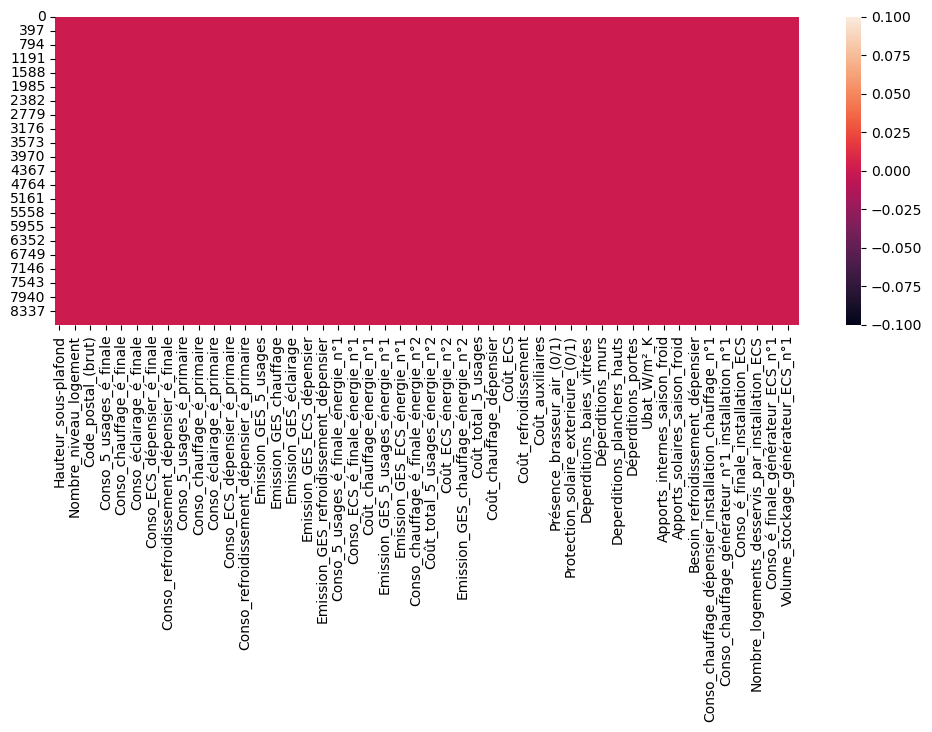

In [134]:
# visualison maintenant notre df_quant
plt.figure(figsize=(12, 4))
sns.heatmap(df_quant.isnull())
plt.show()

In [135]:
df_quant = df_quant.astype('float')

In [136]:
df_quant.shape

(8718, 96)

Après le nettoyage, il reste 96 variables quantitatives exploitables. On peut maintenant s’intéresser aux variables qualitatives, afin d’observer les grandes tendances du jeu de données et de mieux comprendre la répartition des différentes catégories.

**Traitement des variables qualitatives**

In [176]:
df_qual = df.select_dtypes(exclude=['number'])   # variables qualitatives

In [177]:
df_qual.shape

(8718, 57)

In [178]:
df_qual.sample(5)

,N°DPE,Date_réception_DPE,Date_établissement_DPE,Date_visite_diagnostiqueur,Modèle_DPE,Date_fin_validité_DPE,N°_DPE_immeuble_associé,Méthode_application_DPE,Etiquette_GES,Etiquette_DPE,Type_bâtiment,Type_installation_chauffage,Type_installation_ECS_(général),Période_construction,Classe_inertie_bâtiment,Classe_altitude,Zone_climatique_,Adresse_brute,Nom__commune_(BAN),Code_INSEE_(BAN),N°_voie_(BAN),Identifiant__BAN,Adresse_(BAN),Nom__rue_(BAN),Complément_d'adresse_bâtiment,Complément_d'adresse_logement,Statut_géocodage,N°_département_(BAN),Type_énergie_n°1,Type_énergie_n°2,Indicateur_confort_été,Qualité_isolation_enveloppe,Qualité_isolation_menuiseries,Qualité_isolation_murs,Qualité_isolation_plancher_bas,Qualité_isolation_plancher_haut_toit_terrase,Qualité_isolation_plancher_haut_comble_perdu,Besoin_ECS,Besoin_refroidissement,Type_énergie_principale_chauffage,Description_installation_chauffage_n°1,Configuration_installation_chauffage_n°1,Type_installation_chauffage_n°1,Type_émetteur_installation_chauffage_n°1,Description_générateur_chauffage_n°1_installation_n°1,Type_énergie_générateur_n°1_installation_n°1,Type_générateur_n°1_installation_n°1,Usage_générateur_n°1_installation_n°1,Type_énergie_principale_ECS,Description_installation_ECS,Configuration_installation_ECS,Type_installation_ECS,Description_générateur_ECS_n°1,Type_énergie_générateur_ECS_n°1,Type_générateur_ECS_n°1,Usage_générateur_ECS_n°1,Catégorie_ENR
8275,2437E4540844K,2024-12-23,2024-12-22,2024-12-18,DPE 3CL 2021 méthode logement,2034-12-21,NaN,dpe maison individuelle,B,D,maison,NaN,NaN,1983-1988,Moyenne,inférieur à 400m,H2b,2 RUE DES AUBUIS,Saint-Branchs,37211,2,37211_0013_00002,2 Rue des Aubuis 37320 Saint-Branchs,Rue des Aubuis,23/IMO/0005,NaN,adresse géocodée ban à l'adresse,37,Bois – Granulés (pellets) ou briquettes,Électricité,moyen,bonne,moyenne,insuffisante,insuffisante,NaN,bonne,"1192,9",0,Bois – Granulés (pellets) ou briquettes,Poêle à granulés flamme verte installé entre 2...,Installation de chauffage simple,installation individuelle,Poêle bois,Bois - Poêle à granulés flamme verte installé ...,Bois – Granulés (pellets) ou briquettes,Poêle à granulés flamme verte installé entre 2...,chauffage,Électricité,Ballon électrique à accumulation vertical (cat...,Un seul système d'ECS sans solaire,installation individuelle,Electrique - Ballon électrique à accumulation ...,Électricité,Ballon électrique à accumulation vertical Caté...,ecs,chauffage au bois
3622,2457E4551615L,2024-12-23,2024-12-22,2024-12-22,DPE 3CL 2021 méthode logement,2034-12-21,2457E4546535B,dpe appartement généré à partir des données DP...,D,D,appartement,individuel,individuel,1948-1974,Lourde,inférieur à 400m,H1b,63/65/67 RUE DU ROCHER,Forbach,57227,67,57227_0980_00067,67 Rue du Rocher 57600 Forbach,Rue du Rocher,002EW478903,2270002060,adresse non géocodée ban car aucune correspond...,57,Gaz naturel,Électricité,NaN,insuffisante,bonne,moyenne,bonne,moyenne,NaN,"53536,7",0,Gaz naturel,Chaudière individuelle gaz standard installée ...,Installation de chauffage simple,installation individuelle,Radiateur bitube avec robinet thermostatique s...,Gaz Naturel - Chaudière gaz standard installée...,Gaz naturel,Chaudière gaz standard après 2015,chauffage + ecs,Gaz naturel,Combiné au système de chauffage,Un seul système d'ECS sans solaire,installation individuelle,Gaz Naturel - Chaudière gaz standard installée...,Gaz naturel,Chaudière gaz standard après 2015,chauffage + ecs,NaN
1583,2442E4541934N,2024-12-23,2024-12-22,2024-12-18,DPE 3CL 2021 méthode logement,2034-12-21,2442E4541880L,dpe appartement généré à partir des données DP...,B,E,appartement,individuel,individuel,1948-1974,Lourde,supérieur à 800m,H1c,Immeuble ALH-C506-1\n1 à 3 parcs des Tilleuls,Saint-Bonnet-le-Château,42204,3,42204_0234_00003,3 Rue des Murailles 42380 Saint-Bonnet-le-Château,Rue des Murailles,2024/442/DPE/GB,428364 BAT:C506-1 - ENT:C506-1-2 - MOD:428364 ...,adresse géocodée ban à l'adresse,42,Électricité,NaN,NaN,moyenne,insuffisante,b

In [179]:
df_qual.nunique()

N°DPE                                                    8718
Date_réception_DPE                                          2
Date_établissement_DPE                                      8
Date_visite_diagnostiqueur                                  8
Modèle_DPE                                                  1
Date_fin_validité_DPE                                       8
N°_DPE_immeuble_associé                                    89
Méthode_application_DPE                                     4
Etiquette_GES                                               7
Etiquette_DPE                                               7
Type_bâtiment                                               3
Type_installation_chauffage                                 3
Type_installation_ECS_(général)                             3
Période_construction                                       10
Classe_inertie_bâtiment                                     4
Classe_altitude                                             3
Zone_cli

In [180]:
var_conserv=[
    # 🔥 Ordinales
    "Etiquette_GES",
    "Etiquette_DPE",
    "Période_construction",
    "Classe_inertie_bâtiment",
    "Classe_altitude",
    "Indicateur_confort_été",
    "Qualité_isolation_enveloppe",
    "Qualité_isolation_menuiseries",
    "Qualité_isolation_murs",
    "Qualité_isolation_plancher_bas",
    "Besoin_ECS",
    "Besoin_refroidissement",
    # 🏠 Structure & énergie
    "Type_bâtiment",
    "Type_installation_chauffage",
    "Type_installation_ECS_(général)",
    "Zone_climatique_",
    "Type_énergie_n°1",
    "Type_énergie_n°2",
    "Type_énergie_principale_chauffage",
    "Type_énergie_principale_ECS",
    "Catégorie_ENR"]
df_qual = df_qual[var_conserv]

(8718, 21)


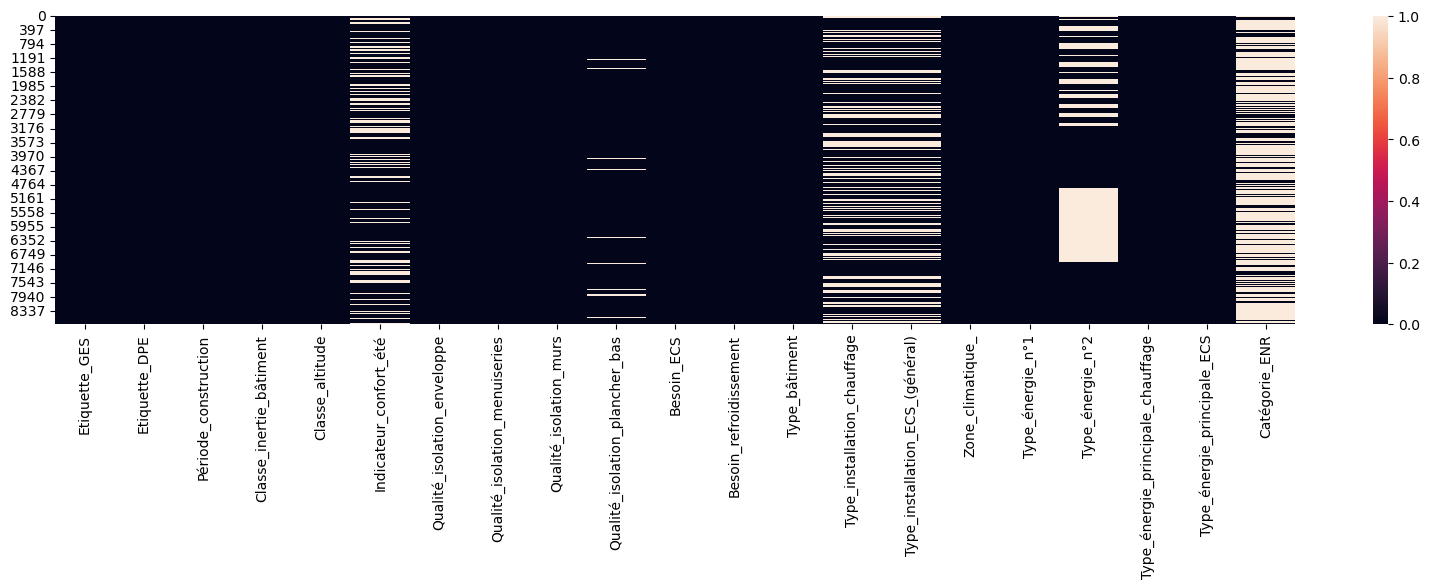

In [181]:
# visualisation de notre dataset pour identifier les valeur vide
print(df_qual.shape)
plt.figure(figsize=(20, 4))
sns.heatmap(df_qual.isnull())
plt.show()

In [182]:
df_qual.head()

,Etiquette_GES,Etiquette_DPE,Période_construction,Classe_inertie_bâtiment,Classe_altitude,Indicateur_confort_été,Qualité_isolation_enveloppe,Qualité_isolation_menuiseries,Qualité_isolation_murs,Qualité_isolation_plancher_bas,Besoin_ECS,Besoin_refroidissement,Type_bâtiment,Type_installation_chauffage,Type_installation_ECS_(général),Zone_climatique_,Type_énergie_n°1,Type_énergie_n°2,Type_énergie_principale_chauffage,Type_énergie_principale_ECS,Catégorie_ENR
0,C,F,1978-1982,Lourde,400-800m,insuffisant,bonne,moyenne,moyenne,moyenne,"1430,4",0,maison,NaN,NaN,H1c,Électricité,Bois – Bûches,Électricité,Électricité,chauffage au bois
1,B,D,1989-2000,Légère,inférieur à 400m,moyen,bonne,bonne,moyenne,bonne,"1084,4",0,maison,NaN,NaN,H2a,Électricité,NaN,Électricité,Électricité,chauffe-eau thermodynamique
2,B,D,1948-1974,Très lourde,inférieur à 400m,NaN,moyenne,très bonne,insuffisante,insuffisante,"18727,3",0,appartement,mixte (collectif-individuel),collectif,H1a,Électricité,NaN,Électricité,Électricité,panneaux solaires thermiques
3,B,D,après 2021,Légère,inférieur à 400m,insuffisant,insuffisante,insuffisante,insuffisante,très bonne,"861,9",0,appartement,mixte (collectif-individuel),individuel,H2c,Électricité,NaN,Électricité,Électricité,NaN
4,A,C,2006-2012,Légère,inférieur à 400m,moyen,très bonne,bonne,bonne,bonne,"1275,2","682,1",maison,NaN,NaN,H2c,Électricité,NaN,Électricité,Électricité,Il existe plusieurs descriptifs ENR


In [183]:
# on supprimera finalement ces variables  car leur information est déjà capturée de manière plus précise par les variables quantitatives déja disponibles.
df_qual=df_qual.drop(['Catégorie_ENR','Type_énergie_n°1', 'Type_énergie_n°2','Type_énergie_principale_chauffage', 'Type_installation_chauffage','Type_installation_ECS_(général)'],axis=1,  errors='ignore')

In [184]:
# on supprimera finalement "Qualité_isolation_plancher_haut_toit_terrase" et "Qualité_isolation_plancher_haut_comble_perdu car elle contiennet trop de valuers manquantes 
df_qual=df_qual.drop(["Qualité_isolation_plancher_haut_toit_terrase","Qualité_isolation_plancher_haut_comble_perdu"],axis=1,  errors='ignore')

In [185]:
df_qual.columns

Index(['Etiquette_GES', 'Etiquette_DPE', 'Période_construction',
       'Classe_inertie_bâtiment', 'Classe_altitude', 'Indicateur_confort_été',
       'Qualité_isolation_enveloppe', 'Qualité_isolation_menuiseries',
       'Qualité_isolation_murs', 'Qualité_isolation_plancher_bas',
       'Besoin_ECS', 'Besoin_refroidissement', 'Type_bâtiment',
       'Zone_climatique_', 'Type_énergie_principale_ECS'],
      dtype='object')

In [186]:
sum_nan_col= df_qual.isna().sum()
sum_nan_col[sum_nan_col != 0]

Indicateur_confort_été            2253
Qualité_isolation_murs               5
Qualité_isolation_plancher_bas     434
Type_énergie_principale_ECS         15
dtype: int64

In [187]:
# Les variables Besoin_ECS et Besoin_refroidissement seront supprimées car elles ne sont pas importantes pour l’analyse 
# et apportent peu d’information supplémentaire par rapport aux variables de consommation déjà présentes.
df_qual = df_qual.drop(["Besoin_ECS", "Besoin_refroidissement","Type_énergie_principale_ECS"], axis=1,  errors='ignore')

In [188]:
for col in df_qual.select_dtypes("object").columns :
    df_qual[col] = df_qual[col].fillna( df_qual[col].mode()[0])

In [189]:
df_qual.shape

(8718, 12)

Les variables qualitatives sont désormais nettoyées et prêtes à être explorées. Cette étape permet de passer à une analyse plus descriptive du jeu de données, en observant la répartition des différentes modalités.

# Analyse exploratoire des données

## Exploration des variables qualitatives

In [190]:
df_qual.describe()

,Etiquette_GES,Etiquette_DPE,Période_construction,Classe_inertie_bâtiment,Classe_altitude,Indicateur_confort_été,Qualité_isolation_enveloppe,Qualité_isolation_menuiseries,Qualité_isolation_murs,Qualité_isolation_plancher_bas,Type_bâtiment,Zone_climatique_
count,8718,8718,8718,8718,8718,8718,8718,8718,8718,8718,8718,8718
unique,7,7,10,4,3,3,4,4,4,4,3,8
top,C,D,1948-1974,Légère,inférieur à 400m,insuffisant,insuffisante,moyenne,insuffisante,insuffisante,appartement,H1a
freq,2366,2923,2709,2925,8226,5116,4821,3924,5066,3945,5792,3328


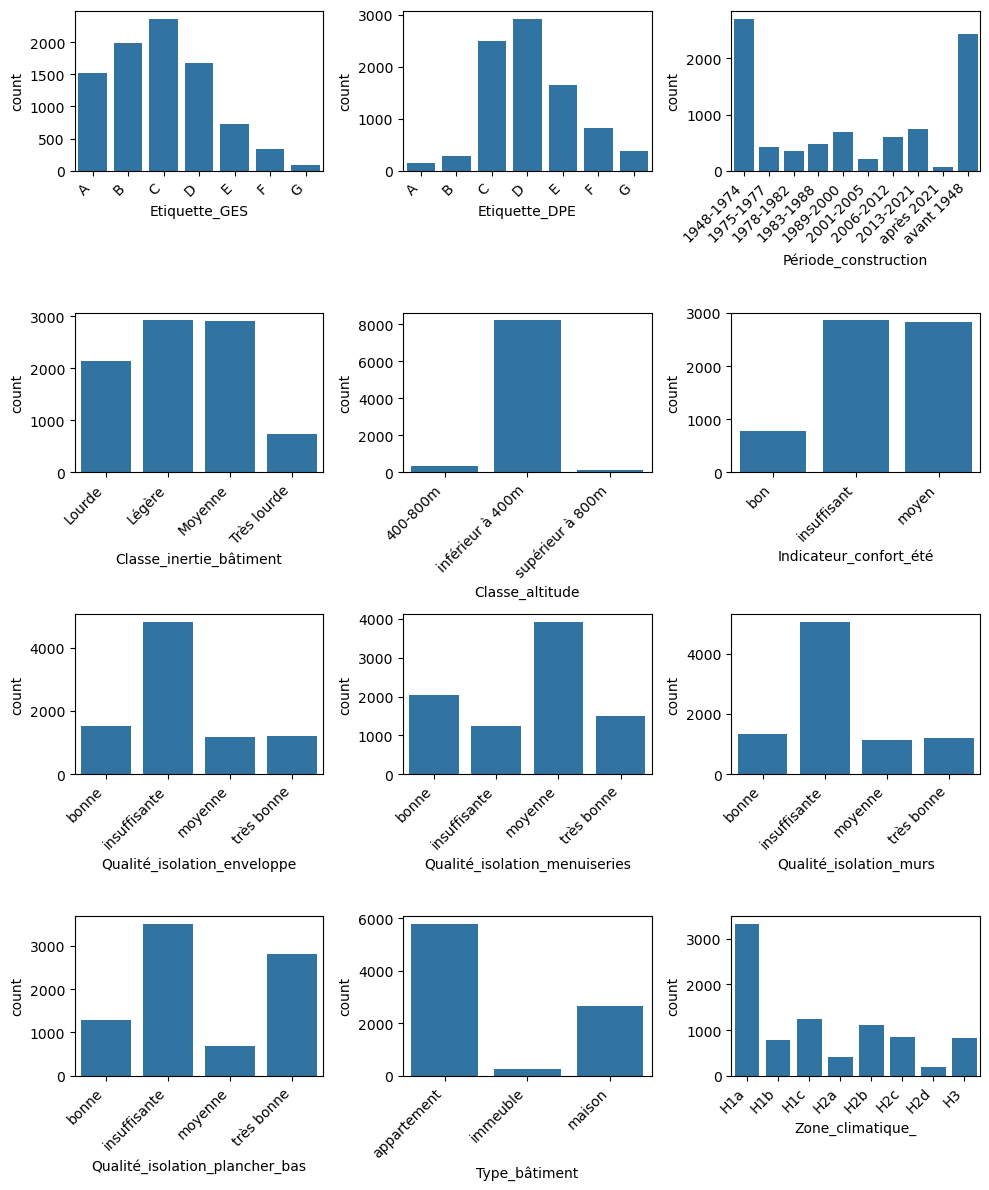

In [170]:
n_lignes = (len(df_qual.columns) + 2) // 3
plt.figure(figsize=(10, 3 * n_lignes))
for i, colonne in enumerate(df_qual.columns):
    plt.subplot(n_lignes, 3, i + 1)  # Créer un subplot
    sns.countplot(data=df, x=colonne, order=sorted(list(df_qual[colonne].unique())))
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()  
plt.show()

***1. Étiquette_GES*** \
    La majorité des logements se situe dans les classes C et D, ce qui correspond à des émissions de gaz à effet de serre modérées. On observe également une présence non négligeable de logements en classe B, tandis que les classes les plus élevées (F et G) restent minoritaires. Cela traduit globalement une situation plutôt correcte en termes d’émissions.

***2. Étiquette_DPE*** \
    Les logements sont majoritairement classés en D et E, ce qui met en évidence une performance énergétique globalement moyenne à faible. Les classes A et B restent peu représentées, ce qui souligne un potentiel important d’amélioration énergétique du parc étudié.

***3. Période_construction*** \
    Une grande partie des logements a été construite avant 1974. Ces bâtiments ont été réalisés avant les premières réglementations thermiques, ce qui explique en partie leurs performances énergétiques limitées et les besoins en rénovation.

***4. Classe_inertie_bâtiment*** \
    Les bâtiments présentent principalement une inertie légère à moyenne. Cela signifie qu’ils ont une capacité limitée à conserver la chaleur, ce qui peut entraîner des variations de température plus importantes et un confort thermique moins stable.

***5. Classe_altitude*** \
    La très grande majorité des logements se situe à une altitude inférieure à 400 mètres. Cette répartition est cohérente avec la géographie du territoire et n’a pas d’impact majeur différenciant sur l’analyse.

***6. Indicateur_confort_été*** \
    Le confort d’été est majoritairement jugé insuffisant à moyen. Cela peut s’expliquer par une isolation thermique peu performante ou un manque de dispositifs adaptés pour limiter les apports de chaleur en période estivale.

***7. Qualité_isolation_enveloppe*** \
L’isolation globale de l’enveloppe des bâtiments est souvent jugée insuffisante. Cela entraîne des pertes thermiques importantes et impacte directement les performances énergétiques.

***8. Qualité_isolation_menuiseries*** \
    Les menuiseries présentent majoritairement une qualité moyenne à insuffisante, ce qui contribue aux déperditions de chaleur, notamment au niveau des fenêtres.

***9. Qualité_isolation_murs***
    Une part importante des logements possède des murs mal isolés. Cela constitue un facteur clé expliquant les mauvaises performances énergétiques observées.

***10. Qualité_isolation_plancher_bas*** \
    On retrouve également une isolation insuffisante au niveau des planchers bas, ce qui accentue les pertes de chaleur et dégrade le confort thermique.

***11. Type_bâtiment*** \
Les logements étudiés sont principalement des appartements, ce qui reflète une forte présence d’habitat collectif dans le jeu de données.

***12. Zone_climatique*** \
    La majorité des logements se situe en zone H1a, correspondant à des zones climatiques relativement froides, ce qui peut influencer les besoins en chauffage.

***Conclusion*** \
Globalement, les logements présentent des émissions de gaz à effet de serre relativement maîtrisées, mais des performances énergétiques encore insuffisantes. Cela s’explique notamment par l’ancienneté des bâtiments et la qualité moyenne à faible de l’isolation. Des travaux de rénovation, en particulier sur l’enveloppe thermique, apparaissent donc nécessaires pour améliorer l’efficacité énergétique et le confort des logements.

Pour pouvoir exploiter cette variable dans les analyses statistiques, il est nécessaire de transformer ses modalités textuelles en valeurs numériques ordonnées.

In [191]:
# dictionnaires
etiquette = {"A": 6, "B": 5, "C": 4, "D": 3, "E": 2, "F": 1, "G": 0}

periode = {
    "avant 1948": 0,
    "1948-1974": 1,
    "1975-1977": 2,
    "1978-1982": 3,
    "1983-1988": 4,
    "1989-2000": 5,
    "2001-2005": 6,
    "2006-2012": 7,
    "2013-2021": 8,
    "après 2021": 9
}

classe_iner_bat = {
    "Légère": 0,
    "Moyenne": 1,
    "Lourde": 2,
    "Très lourde": 3
}

altitude = {
    "inférieur à 400m": 0,
    "400-800m": 1,
    "supérieur à 800m": 2
}

indicateur = {"insuffisant": 0, "moyen": 1, "bon": 2}

qualite = {"insuffisante": 0, "moyenne": 1, "bonne": 2, "très bonne": 3}

# remplacements
df_qual[["Etiquette_GES", "Etiquette_DPE"]] = df_qual[["Etiquette_GES", "Etiquette_DPE"]].replace(etiquette)
df_qual["Période_construction"] = df_qual["Période_construction"].replace(periode)
df_qual["Classe_inertie_bâtiment"] = df_qual["Classe_inertie_bâtiment"].replace(classe_iner_bat)
df_qual["Classe_altitude"] = df_qual["Classe_altitude"].replace(altitude)
df_qual["Indicateur_confort_été"] = df_qual["Indicateur_confort_été"].replace(indicateur)

df_qual[[
    "Qualité_isolation_enveloppe",
    "Qualité_isolation_menuiseries",
    "Qualité_isolation_murs",
    "Qualité_isolation_plancher_bas"
]] = df_qual[[
    "Qualité_isolation_enveloppe",
    "Qualité_isolation_menuiseries",
    "Qualité_isolation_murs",
    "Qualité_isolation_plancher_bas"
]].replace(qualite)

# one-hot encoding des variables nominales
df_qual = pd.get_dummies(
    df_qual,
    columns=["Type_bâtiment", "Zone_climatique_"],
    drop_first=True
)

# garder toutes les colonnes numériques
df_qual = df_qual.select_dtypes(include="number")

# aperçu
df_qual.head()

,Etiquette_GES,Etiquette_DPE,Période_construction,Classe_inertie_bâtiment,Classe_altitude,Indicateur_confort_été,Qualité_isolation_enveloppe,Qualité_isolation_menuiseries,Qualité_isolation_murs,Qualité_isolation_plancher_bas
0,4,1,3,2,1,0,2,1,1,1
1,5,3,5,0,0,1,2,2,1,2
2,5,3,1,3,0,0,1,3,0,0
3,5,3,9,0,0,0,0,0,0,3
4,6,4,7,0,0,1,3,2,2,2


In [192]:
df_qual.shape

(8718, 10)

In [193]:
df_qual.dtypes

Etiquette_GES                     int64
Etiquette_DPE                     int64
Période_construction              int64
Classe_inertie_bâtiment           int64
Classe_altitude                   int64
Indicateur_confort_été            int64
Qualité_isolation_enveloppe       int64
Qualité_isolation_menuiseries     int64
Qualité_isolation_murs            int64
Qualité_isolation_plancher_bas    int64
dtype: object

## Exploration des variables quantitatives

In [194]:
# Dimensions du jeu de données
print(f"Le jeu de données contient {df_quant.shape[0]} lignes et {df_quant.shape[1]} variables quantitatives.")

Le jeu de données contient 8718 lignes et 96 variables quantitatives.


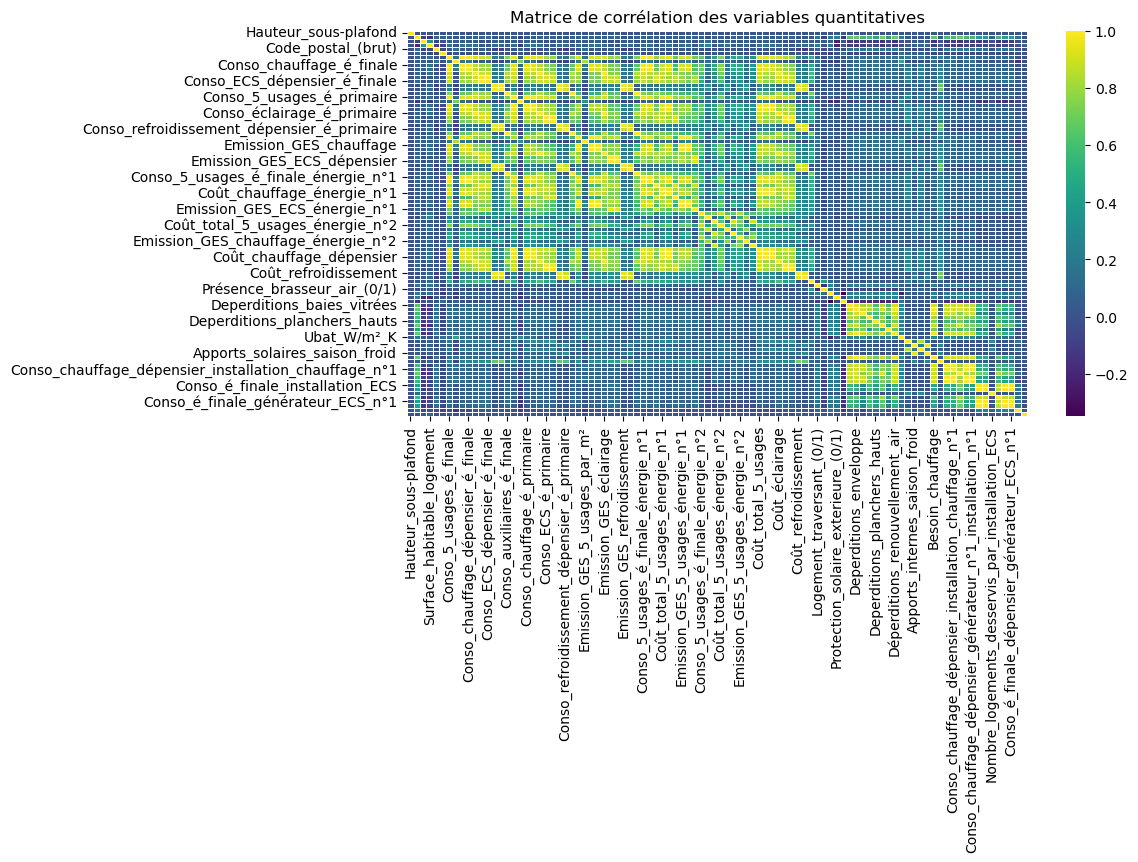

In [198]:
# Matrice de corrélation
plt.figure(figsize=(10, 5))

corr = df_quant.corr()

sns.heatmap(
    corr,
    cmap="viridis",
    annot=False,
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables quantitatives")
plt.show()

Cette matrice de corrélation met en évidence la présence de fortes corrélations positives entre plusieurs groupes de variables, notamment celles liées aux consommations énergétiques, aux coûts et aux émissions de gaz à effet de serre.
Ces relations apparaissent sous forme de zones plus claires, indiquant que certaines variables évoluent de manière similaire et traduisent une information redondante.
À l’inverse, on observe peu de corrélations négatives marquées, ce qui signifie que les variables varient globalement dans le même sens.
Dans ce contexte, il sera pertinent d’identifier ces variables fortement corrélées afin de réduire la dimension du jeu de données et d’éviter les redondances, notamment dans la perspective d’une ACP ou d’une modélisation.

## Fusion de df_quant et df_qual

In [199]:
df_nettoye = pd.concat([df_quant, df_qual], axis=1)
df_nettoye.shape

(8718, 106)

# Création de fonctions

### Régression linéaire

In [234]:
# Fonction pour faire une régression linéaire multiple
def linearRegressionFit(x, y):
    """
    Ajuste un modèle de régression linéaire multiple par la méthode des moindres carrés.

    Cette fonction estime les coefficients du modèle :
        y = b0 + b1*x1 + b2*x2 + ... + bp*xp + e

    Un terme constant est automatiquement ajouté afin d'estimer l'ordonnée à l'origine.

    Paramètres
    ----------
    x : array-like de forme (n, p)
        Matrice des variables explicatives, avec n observations et p variables.
    y : array-like de forme (n,) ou (n, 1)
        Variable à expliquer.

    Retour
    ------
    m : ndarray de forme (p+1,)
        Vecteur des coefficients estimés, avec le terme constant en première position.

    Exemple
    -------
    >>> m = linearRegressionFit(X, y)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    X = np.column_stack((np.ones(x.shape[0]), x))
    m = np.linalg.inv(X.T @ X) @ X.T @ y

    return m.flatten()

In [235]:
def cal_ic(x, y, m, level=0.95):
    """
    Calcule les intervalles de confiance des coefficients d'un modèle de régression linéaire.

    Paramètres
    ----------
    x : array-like de forme (n, p)
        Matrice des variables explicatives.
    y : array-like de forme (n,) ou (n, 1)
        Variable expliquée.
    m : array-like de forme (p+1,)
        Coefficients estimés du modèle, incluant l'ordonnée à l'origine.
    level : float, optionnel
        Niveau de confiance souhaité. Par défaut : 0.95.

    Retour
    ------
    ic : list de tuples
        Liste contenant, pour chaque coefficient, un intervalle de confiance
        sous la forme (borne_inf, borne_sup).

    Remarque
    --------
    Cette fonction suppose que les hypothèses classiques de la régression linéaire
    sont raisonnablement vérifiées.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1, 1)
    m = np.asarray(m, dtype=float).reshape(-1, 1)

    X = np.column_stack((np.ones(x.shape[0]), x))
    n, p = X.shape

    y_pred = X @ m
    residus = y - y_pred

    sigma2 = (residus.T @ residus) / (n - p)
    var_beta = sigma2[0, 0] * np.linalg.inv(X.T @ X)
    se_beta = np.sqrt(np.diag(var_beta))

    alpha = 1 - level
    t_crit = t.ppf(1 - alpha / 2, df=n - p)

    ic = []
    for i in range(len(m)):
        borne_inf = m[i, 0] - t_crit * se_beta[i]
        borne_sup = m[i, 0] + t_crit * se_beta[i]
        ic.append((borne_inf, borne_sup))

    return ic


In [236]:
def predict(x, m):
    """
    Produit les prédictions d'un modèle de régression linéaire.

    Paramètres
    ----------
    x : array-like de forme (n, p)
        Matrice des variables explicatives.
    m : array-like de forme (p+1,)
        Coefficients du modèle, avec constante en première position.

    Retour
    ------
    y_pred : ndarray de forme (n,)
        Valeurs prédites par le modèle.
    """
    x = np.asarray(x, dtype=float)
    m = np.asarray(m, dtype=float).reshape(-1, 1)

    X = np.column_stack((np.ones(x.shape[0]), x))
    y_pred = X @ m

    return y_pred.flatten()


In [237]:
def cal_coeff_determination(x, y, m):
    """
    Calcule le coefficient de détermination R² d'un modèle de régression linéaire.

    Paramètres
    ----------
    x : array-like de forme (n, p)
        Matrice des variables explicatives.
    y : array-like de forme (n,)
        Variable expliquée.
    m : array-like de forme (p+1,)
        Coefficients estimés du modèle.

    Retour
    ------
    r2 : float
        Coefficient de détermination du modèle.

    Interprétation
    --------------
    Plus R² est proche de 1, plus le modèle explique une grande part de la variabilité de y.
    """
    y = np.asarray(y, dtype=float).flatten()
    y_pred = predict(x, m)

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - ss_res / ss_tot
    return r2

### ACP

In [238]:
# cette fonction normalise nos données
def normalisation(x):
    """
    Centre et réduit les données.

    Paramètres
    ----------
    x : array-like de forme (n, p)
        Matrice de données contenant n individus et p variables.

    Retour
    ------
    x_norm : ndarray de forme (n, p)
        Données centrées-réduites.

    Remarque
    --------
    Chaque variable est transformée pour avoir une moyenne nulle
    et un écart-type égal à 1.
    """
    x = np.asarray(x, dtype=float)
    moy = np.mean(x, axis=0)
    std = np.std(x, axis=0, ddof=0)

    x_norm = (x - moy) / std
    return x_norm


In [239]:
# cette fonction retourne la matrice de corrélation
def mat_coef_corr(x):
    """
    Calcule la matrice de corrélation des variables.

    Paramètres
    ----------
    x : array-like de forme (n, p)
        Matrice des données centrées-réduites.

    Retour
    ------
    coef_mat : ndarray de forme (p, p)
        Matrice de corrélation des variables.
    """
    x = np.asarray(x, dtype=float)
    return np.corrcoef(x, rowvar=False)


In [240]:
# détermination des valeurs propres et vecteurs propres
def det_val_and_vec_propre(coef_mat):
    """
    Calcule les valeurs propres et vecteurs propres d'une matrice carrée.

    Paramètres
    ----------
    coef_mat : ndarray de forme (p, p)
        Matrice carrée, généralement la matrice de corrélation.

    Retour
    ------
    val_p : ndarray
        Valeurs propres triées dans l'ordre décroissant.
    vec_p : ndarray
        Vecteurs propres associés, triés selon les valeurs propres.
    """
    val_p, vec_p = np.linalg.eigh(coef_mat)

    ordre = np.argsort(val_p)[::-1]
    val_p = val_p[ordre]
    vec_p = vec_p[:, ordre]

    return val_p, vec_p

In [241]:
# inertie expliquée
def inertie_explique(val_p):
    """
    Calcule la proportion d'inertie expliquée par chaque composante principale.

    Paramètres
    ----------
    val_p : ndarray
        Valeurs propres de l'ACP.

    Retour
    ------
    inertie : ndarray
        Pourcentage d'inertie expliquée par chaque axe.
    inertie_cumulee : ndarray
        Pourcentage cumulé d'inertie expliquée.
    """
    val_p = np.asarray(val_p, dtype=float)
    inertie = val_p / np.sum(val_p)
    inertie_cumulee = np.cumsum(inertie)

    return inertie, inertie_cumulee


In [242]:
# cette fonction projette nos données
def projecter(data, base):
    """
    Projette les données dans la base des composantes principales.

    Paramètres
    ----------
    data : array-like de forme (n, p)
        Matrice des données centrées-réduites.
    base : ndarray de forme (p, k)
        Base de projection, généralement constituée des vecteurs propres.

    Retour
    ------
    data_proj : ndarray de forme (n, k)
        Coordonnées des individus dans le nouvel espace.
    """
    data = np.asarray(data, dtype=float)
    return data @ base

In [243]:
def contribution_individu(data_proj, val_p):
    """
    Calcule la contribution des individus aux axes factoriels.

    Paramètres
    ----------
    data_proj : ndarray de forme (n, k)
        Coordonnées des individus projetés.
    val_p : ndarray
        Valeurs propres associées aux axes.

    Retour
    ------
    contrib : ndarray de forme (n, k)
        Contribution de chaque individu à chaque axe.
    """
    data_proj = np.asarray(data_proj, dtype=float)
    val_p = np.asarray(val_p, dtype=float)

    contrib = (data_proj ** 2) / (data_proj.shape[0] * val_p)
    return contrib


In [244]:
def qualite_representation(data_proj):
    """
    Calcule la qualité de représentation (cos²) des individus sur les axes.

    Paramètres
    ----------
    data_proj : ndarray de forme (n, k)
        Coordonnées des individus projetés.

    Retour
    ------
    cos2 : ndarray de forme (n, k)
        Qualité de représentation de chaque individu sur chaque axe.
    """
    data_proj = np.asarray(data_proj, dtype=float)
    dist2 = np.sum(data_proj ** 2, axis=1).reshape(-1, 1)

    cos2 = (data_proj ** 2) / dist2
    return cos2

In [245]:
def corr_vec_p_var(vec_p, val_p):
    """
    Calcule les corrélations entre les variables initiales et les composantes principales.

    Paramètres
    ----------
    vec_p : ndarray
        Vecteurs propres.
    val_p : ndarray
        Valeurs propres.

    Retour
    ------
    corr : ndarray
        Corrélations variables/composantes.
    """
    return vec_p * np.sqrt(val_p)


In [246]:
def cercle_corr(val_p, vec_p, list_col=None, list_col_to_print=None, indice_base=(0, 1), ax=None):
    """
    Trace un cercle de corrélation pour visualiser la relation entre les variables
    et les composantes principales.

    Paramètres
    ----------
    val_p : ndarray
        Valeurs propres de l'ACP.
    vec_p : ndarray
        Vecteurs propres associés aux composantes principales.
    list_col : list, optionnel
        Liste des noms de variables.
    list_col_to_print : list, optionnel
        Sous-ensemble de noms à afficher.
    indice_base : tuple, optionnel
        Indices des axes à représenter. Par défaut : (0, 1).
    ax : matplotlib.axes.Axes, optionnel
        Axe matplotlib sur lequel dessiner.

    Retour
    ------
    ax : matplotlib.axes.Axes
        Axe contenant le graphique.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    corr = corr_vec_p_var(vec_p, val_p)
    i, j = indice_base

    cercle = Circle((0, 0), 1, facecolor='none', edgecolor='blue', linestyle='--')
    ax.add_patch(cercle)

    for k in range(corr.shape[0]):
        ax.arrow(0, 0, corr[k, i], corr[k, j],
                 head_width=0.03, head_length=0.03, fc='red', ec='red')

        if list_col is not None:
            nom = list_col[k]
            if (list_col_to_print is None) or (nom in list_col_to_print):
                ax.text(corr[k, i] * 1.1, corr[k, j] * 1.1, nom, fontsize=9)

    ax.axhline(0, color='grey', linewidth=0.8)
    ax.axvline(0, color='grey', linewidth=0.8)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(f"Axe {i+1}")
    ax.set_ylabel(f"Axe {j+1}")
    ax.set_title("Cercle de corrélation")
    ax.set_aspect('equal')

    return ax

In [247]:
def plot_plan_fact(proj, inertie, indice_base=(0, 1), ax=None):
    """
    Trace la projection des individus sur un plan factoriel.

    Paramètres
    ----------
    proj : ndarray de forme (n, k)
        Coordonnées des individus dans l'espace factoriel.
    inertie : ndarray
        Inertie expliquée par chaque axe.
    indice_base : tuple, optionnel
        Axes à représenter. Par défaut : (0, 1).
    ax : matplotlib.axes.Axes, optionnel
        Axe matplotlib sur lequel dessiner.

    Retour
    ------
    ax : matplotlib.axes.Axes
        Axe contenant le plan factoriel.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    i, j = indice_base
    ax.scatter(proj[:, i], proj[:, j], alpha=0.6)

    ax.axhline(0, color='grey', linewidth=0.8)
    ax.axvline(0, color='grey', linewidth=0.8)
    ax.set_xlabel(f"Axe {i+1} ({inertie[i]*100:.2f} %)")
    ax.set_ylabel(f"Axe {j+1} ({inertie[j]*100:.2f} %)")
    ax.set_title("Plan factoriel")

    return ax


In [248]:
def acp(X):
    """
    Réalise une analyse en composantes principales complète.

    Paramètres
    ----------
    X : array-like de forme (n, p)
        Matrice des données initiales.

    Retour
    ------
    resultats : dict
        Dictionnaire contenant :
        - 'X_norm' : données centrées-réduites
        - 'corr' : matrice de corrélation
        - 'val_p' : valeurs propres
        - 'vec_p' : vecteurs propres
        - 'inertie' : inertie expliquée
        - 'inertie_cumulee' : inertie cumulée
        - 'proj' : projection des individus
        - 'contrib' : contribution des individus
        - 'cos2' : qualité de représentation
        - 'corr_var_axes' : corrélation variables / axes
    """
    X_norm = normalisation(X)
    corr = mat_coef_corr(X_norm)
    val_p, vec_p = det_val_and_vec_propre(corr)
    inertie, inertie_cumulee = inertie_explique(val_p)
    proj = projecter(X_norm, vec_p)
    contrib = contribution_individu(proj, val_p)
    cos2 = qualite_representation(proj)
    corr_var_axes = corr_vec_p_var(vec_p, val_p)

    return {
        "X_norm": X_norm,
        "corr": corr,
        "val_p": val_p,
        "vec_p": vec_p,
        "inertie": inertie,
        "inertie_cumulee": inertie_cumulee,
        "proj": proj,
        "contrib": contrib,
        "cos2": cos2,
        "corr_var_axes": corr_var_axes
    }

### Fonctions utilitaires

In [249]:
# fonction pour générer toutes les combinaisons possibles de 2 parmi n d'une liste
def C2n(vec):
    """
    Génère toutes les combinaisons possibles de 2 éléments parmi les éléments d'une liste.

    Paramètres
    ----------
    vec : list
        Liste d'éléments.

    Retour
    ------
    temp : list de listes
        Liste contenant toutes les paires possibles.

    Exemple
    -------
    >>> C2n([1, 2, 3])
    [[1, 2], [1, 3], [2, 3]]
    """
    temp = []
    for i in range(len(vec)):
        for j in range(i + 1, len(vec)):
            temp.append([vec[i], vec[j]])

    return temp


C2n([1, 2, 3])

[[1, 2], [1, 3], [2, 3]]

In [216]:
df_quant.columns

Index(['Hauteur_sous-plafond', 'Nombre_appartement', 'Nombre_niveau_logement',
       'Surface_habitable_logement', 'Code_postal_(brut)',
       'N°_étage_appartement', 'Conso_5_usages_é_finale',
       'Conso_5_usages/m²_é_finale', 'Conso_chauffage_é_finale',
       'Conso_chauffage_dépensier_é_finale', 'Conso_éclairage_é_finale',
       'Conso_ECS_é_finale', 'Conso_ECS_dépensier_é_finale',
       'Conso_refroidissement_é_finale',
       'Conso_refroidissement_dépensier_é_finale',
       'Conso_auxiliaires_é_finale', 'Conso_5_usages_é_primaire',
       'Conso_5_usages_par_m²_é_primaire', 'Conso_chauffage_é_primaire',
       'Conso_chauffage_dépensier_é_primaire', 'Conso_éclairage_é_primaire',
       'Conso_ECS_é_primaire', 'Conso_ECS_dépensier_é_primaire',
       'Conso_refroidissement_é_primaire',
       'Conso_refroidissement_dépensier_é_primaire',
       'Conso_auxiliaires_é_primaire', 'Emission_GES_5_usages',
       'Emission_GES_5_usages_par_m²', 'Emission_GES_chauffage',
       

# Normalisation et matrice de corrélation

Avant de lancer l’ACP, je souhaite m’assurer que mon jeu de données ne contient pas de variables redondantes.  
Dans le cadre du diagnostic de performance énergétique des bâtiments, il est très fréquent que certaines variables soient fortement corrélées entre elles, en particulier les variables liées aux consommations énergétiques.

Par exemple, la variable **`Conso_5_usages_é_finale`** représente la consommation totale pour les cinq usages (chauffage, eau chaude sanitaire, refroidissement, éclairage, auxiliaires).  
Il est donc possible que cette variable soit très fortement liée à d’autres variables comme :

- `Conso_chauffage_é_finale`  
- `Conso_ECS_é_finale`  
- `Conso_refroidissement_é_finale`  
- `Conso_éclairage_é_finale`  
- `Conso_auxiliaires_é_finale`  

En effet, ces variables peuvent, lorsqu’on les additionne, reconstruire presque exactement la consommation totale.  
Dans ce cas, garder toutes ces variables reviendrait à introduire plusieurs fois la même information dans l’analyse.

Or, cela peut poser problème pour l’ACP, car certaines dimensions seraient sur-représentées.  
L’objectif ici est donc de réduire la redondance entre variables quantitatives avant de réaliser l’ACP.

Pour cela, je vais tester toutes les combinaisons possibles de deux variables quantitatives.  
À chaque fois, je modélise une relation de la forme :

$$
y = a + bx
$$

où une variable est expliquée par une autre.

Ensuite, je calcule le coefficient de détermination $R^2$, qui mesure la proportion de variance de $y$ expliquée par $x$.

- Si $R^2$ est proche de 1, cela signifie que la variable $y$ est presque entièrement expliquée par $x$.
- Dans ce cas, les deux variables contiennent quasiment la même information.

J’ai fixé un seuil à $R^2 \geq 0{,}90$.  
Lorsque ce seuil est dépassé, je considère que la variable expliquée est redondante, et je peux donc la supprimer sans perdre d’information significative.

Ce processus est appliqué de manière itérative :

- à chaque suppression de variable, je reconstruis les combinaisons possibles  
- puis je recommence jusqu’à ce qu’il ne reste plus de variables fortement corrélées  

L’objectif est d’obtenir un sous-ensemble de variables quantitatives plus pertinent, moins redondant, et mieux adapté pour la suite de l’analyse.

En parallèle, je conserve les résultats des régressions significatives (coefficients, intervalles de confiance et $R^2$), afin de pouvoir interpréter les relations fortes entre variables dans le contexte énergétique des bâtiments.

# Réduction de dimension par régression linéaire simple

In [250]:
# On récupère la liste des variables quantitatives
# Ce sont elles que l'on va comparer deux à deux
df_quant_col = list(df_quant.columns)

# Dictionnaire qui servira à stocker les relations linéaires fortes trouvées
# Pour chaque paire retenue, on gardera :
# - la variable expliquée (y)
# - la variable explicative (x)
# - les coefficients de régression
# - le R²
# - les intervalles de confiance
df_lin_regression = {
    "y": [],
    "x": [],
    "a": [],
    "b": [],
    "R2": [],
    "ic_a": [],
    "ic_b": []
}

# Génération de toutes les combinaisons possibles de 2 variables quantitatives
# Exemple : [var1, var2], [var1, var3], [var2, var3], etc.
combi_quant_col = C2n(df_quant_col)

# Seuil choisi pour considérer qu'une variable est très bien expliquée par une autre
# Ici, si R² >= 0.90, on considère qu'il y a une forte redondance
seuil = 0.90

# tqdm permet d'afficher une barre de progression pendant l'exécution
with tqdm(total=len(combi_quant_col), desc="Progression", unit="pair") as pbar:
    
    # i représente l'indice de la combinaison actuellement testée
    i = 0
    
    # Tant qu'il reste des paires à tester
    while i < len(combi_quant_col):
        
        # On choisit la première variable de la paire comme variable explicative x
        x = df_quant[combi_quant_col[i][0]].values.reshape(-1, 1)
        
        # On choisit la deuxième variable de la paire comme variable expliquée y
        y = df_quant[combi_quant_col[i][1]].values.reshape(-1, 1)

        # Ajustement de la régression linéaire simple y = a + bx
        m = linearRegressionFit(x, y)
        
        # Calcul des intervalles de confiance des coefficients
        ic = cal_ic(x, y, m)
        
        # Calcul du coefficient de détermination R²
        r2 = cal_coeff_determination(x, y, m)

        # Si le lien entre x et y est très fort, on considère y comme redondante
        if r2 >= seuil:
            
            # On enregistre la relation trouvée
            df_lin_regression["x"].append(combi_quant_col[i][0])   # variable explicative
            df_lin_regression["y"].append(combi_quant_col[i][1])   # variable expliquée
            
            # Coefficients de la droite de régression
            # Ici, avec la fonction linearRegressionFit, m[0] = constante et m[1] = pente
            df_lin_regression["a"].append(m[0])   # constante
            df_lin_regression["b"].append(m[1])   # pente
            
            # Valeur du R²
            df_lin_regression["R2"].append(r2)
            
            # Intervalles de confiance :
            # ic[0] correspond à la constante
            # ic[1] correspond à la pente
            df_lin_regression["ic_a"].append(ic[0])
            df_lin_regression["ic_b"].append(ic[1])

            # On retire la variable y de la liste des variables quantitatives
            # car elle est considérée comme redondante
            df_quant_col.remove(combi_quant_col[i][1])

            # Puisqu'on a supprimé une variable, on doit reconstruire toutes les combinaisons
            combi_quant_col = C2n(df_quant_col)

            # On repart du début pour retester proprement les nouvelles combinaisons
            i = 0

            # On réinitialise la barre de progression avec le nouveau nombre de paires
            pbar.reset(total=len(combi_quant_col))
        
        else:
            # Si la relation n'est pas assez forte, on passe à la paire suivante
            i += 1
            pbar.update(1)

# Transformation du dictionnaire de résultats en DataFrame
df_lin_regression = pd.DataFrame(df_lin_regression)

Progression: 100%|█████████████████████████████████████████████████████████████| 1485/1485 [00:00<00:00, 1912.51pair/s]


In [251]:
# Affiche la dimension du DataFrame résultant :
# (nombre de relations fortes détectées, nombre d'informations stockées)
print(df_lin_regression.shape)

# Affiche les premières lignes du tableau
# Cela permet de voir les premières paires de variables fortement liées
df_lin_regression.head()

(41, 7)


,y,x,a,b,R2,ic_a,ic_b
0,Conso_chauffage_é_finale,Conso_5_usages_é_finale,21.844943,0.759261,0.974822,"(-94.97741486506754, 138.66730104270744)","(0.7566991697550866, 0.7618232880854007)"
1,Conso_chauffage_dépensier_é_finale,Conso_5_usages_é_finale,-56.542692,0.951984,0.977710,"(-194.15771628303273, 81.07233135626049)","(0.9489655351661272, 0.9550016713855247)"
2,Conso_5_usages_é_primaire,Conso_5_usages_é_finale,3139.968237,1.168047,0.912231,"(2793.099715864863, 3486.8367576293663)","(1.1604396504804082, 1.1756541640135396)"
3,Conso_5_usages_é_finale_énergie_n°1,Conso_5_usages_é_finale,-179.602762,0.916400,0.989325,"(-270.7399812594892, -88.46554316514072)","(0.9144010904672167, 0.9183985949079149)"
4,Conso_chauffage_é_finale_énergie_n°1,Conso_5_usages_é_finale,-394.645075,0.744586,0.970594,"(-518.7242411710191, -270.5659089278172)","(0.7418644763649022, 0.7473068962977781)"


À cette étape, j’obtiens un total de 41 relations linéaires fortes entre variables quantitatives, c’est-à-dire des paires pour lesquelles le coefficient de détermination $R^2$ est supérieur à 0,90. Cela signifie que certaines variables peuvent être très largement expliquées par d’autres, ce qui confirme la présence de redondance dans le jeu de données.

En observant les premiers résultats, on remarque que la variable **`Conso_5_usages_é_finale`** apparaît très fréquemment comme variable explicative. Cela est cohérent avec sa définition, puisqu’elle correspond à la consommation totale des cinq usages principaux du logement : chauffage, eau chaude sanitaire, refroidissement, éclairage et auxiliaires.

Par exemple, la variable **`Conso_chauffage_é_finale`** est très fortement expliquée par la consommation totale, avec un coefficient de détermination $R^2 = 0{,}97$. Cela signifie que la consommation liée au chauffage évolue de manière très proche de la consommation totale. On observe également que le coefficient de pente est positif (environ 0,76), ce qui indique que plus la consommation totale augmente, plus la consommation de chauffage augmente également.

De la même manière, la variable **`Conso_chauffage_dépensier_é_finale`** présente un $R^2$ encore plus élevé (0,98), ce qui montre une relation encore plus forte. Cela suggère que les scénarios de consommation “dépensiers” sont très fortement liés à la consommation globale du logement.

On constate également des relations fortes entre les consommations en énergie finale et en énergie primaire. Par exemple, **`Conso_5_usages_é_primaire`** est fortement expliquée par **`Conso_5_usages_é_finale`**, avec un $R^2$ supérieur à 0,91. Cela est logique, car l’énergie primaire est directement dérivée de l’énergie finale via des coefficients de conversion.

De plus, certaines variables spécifiques à une source d’énergie, comme **`Conso_5_usages_é_finale_énergie_n°1`**, présentent un $R^2$ très élevé (0,99) avec la consommation totale. Cela indique que, dans de nombreux cas, une source d’énergie dominante peut expliquer presque entièrement la consommation totale.

Ces résultats confirment donc que plusieurs variables du jeu de données décrivent en réalité des informations très proches, voire redondantes. En particulier, les variables liées aux différentes formes de consommation énergétique (totale, par usage, par type d’énergie, ou en version “dépensier”) sont fortement corrélées entre elles.

Ainsi, cette étape permet d’identifier les variables redondantes qui pourront être supprimées ou réduites dans la suite de l’analyse. Cela permettra d’éviter de sur-représenter certaines dimensions dans l’ACP et d’obtenir une représentation plus fidèle de la structure réelle des données.

Il nous reste  :  55 colonnes


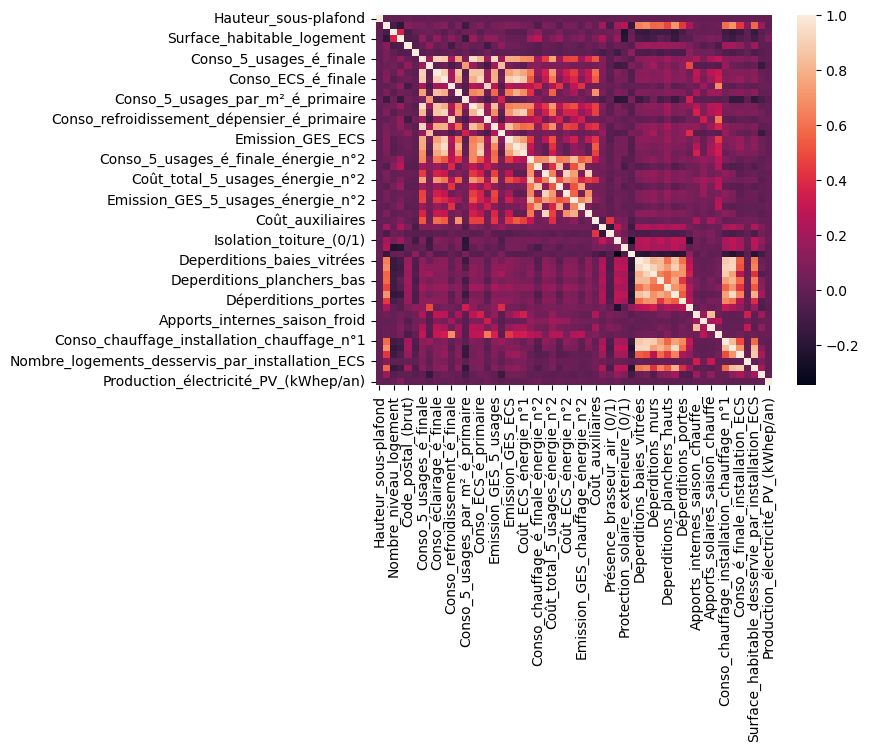

In [252]:
print("Il nous reste  : ", len(df_quant_col), "colonnes")
sns.heatmap(df_quant[df_quant_col].corr())
plt.show()

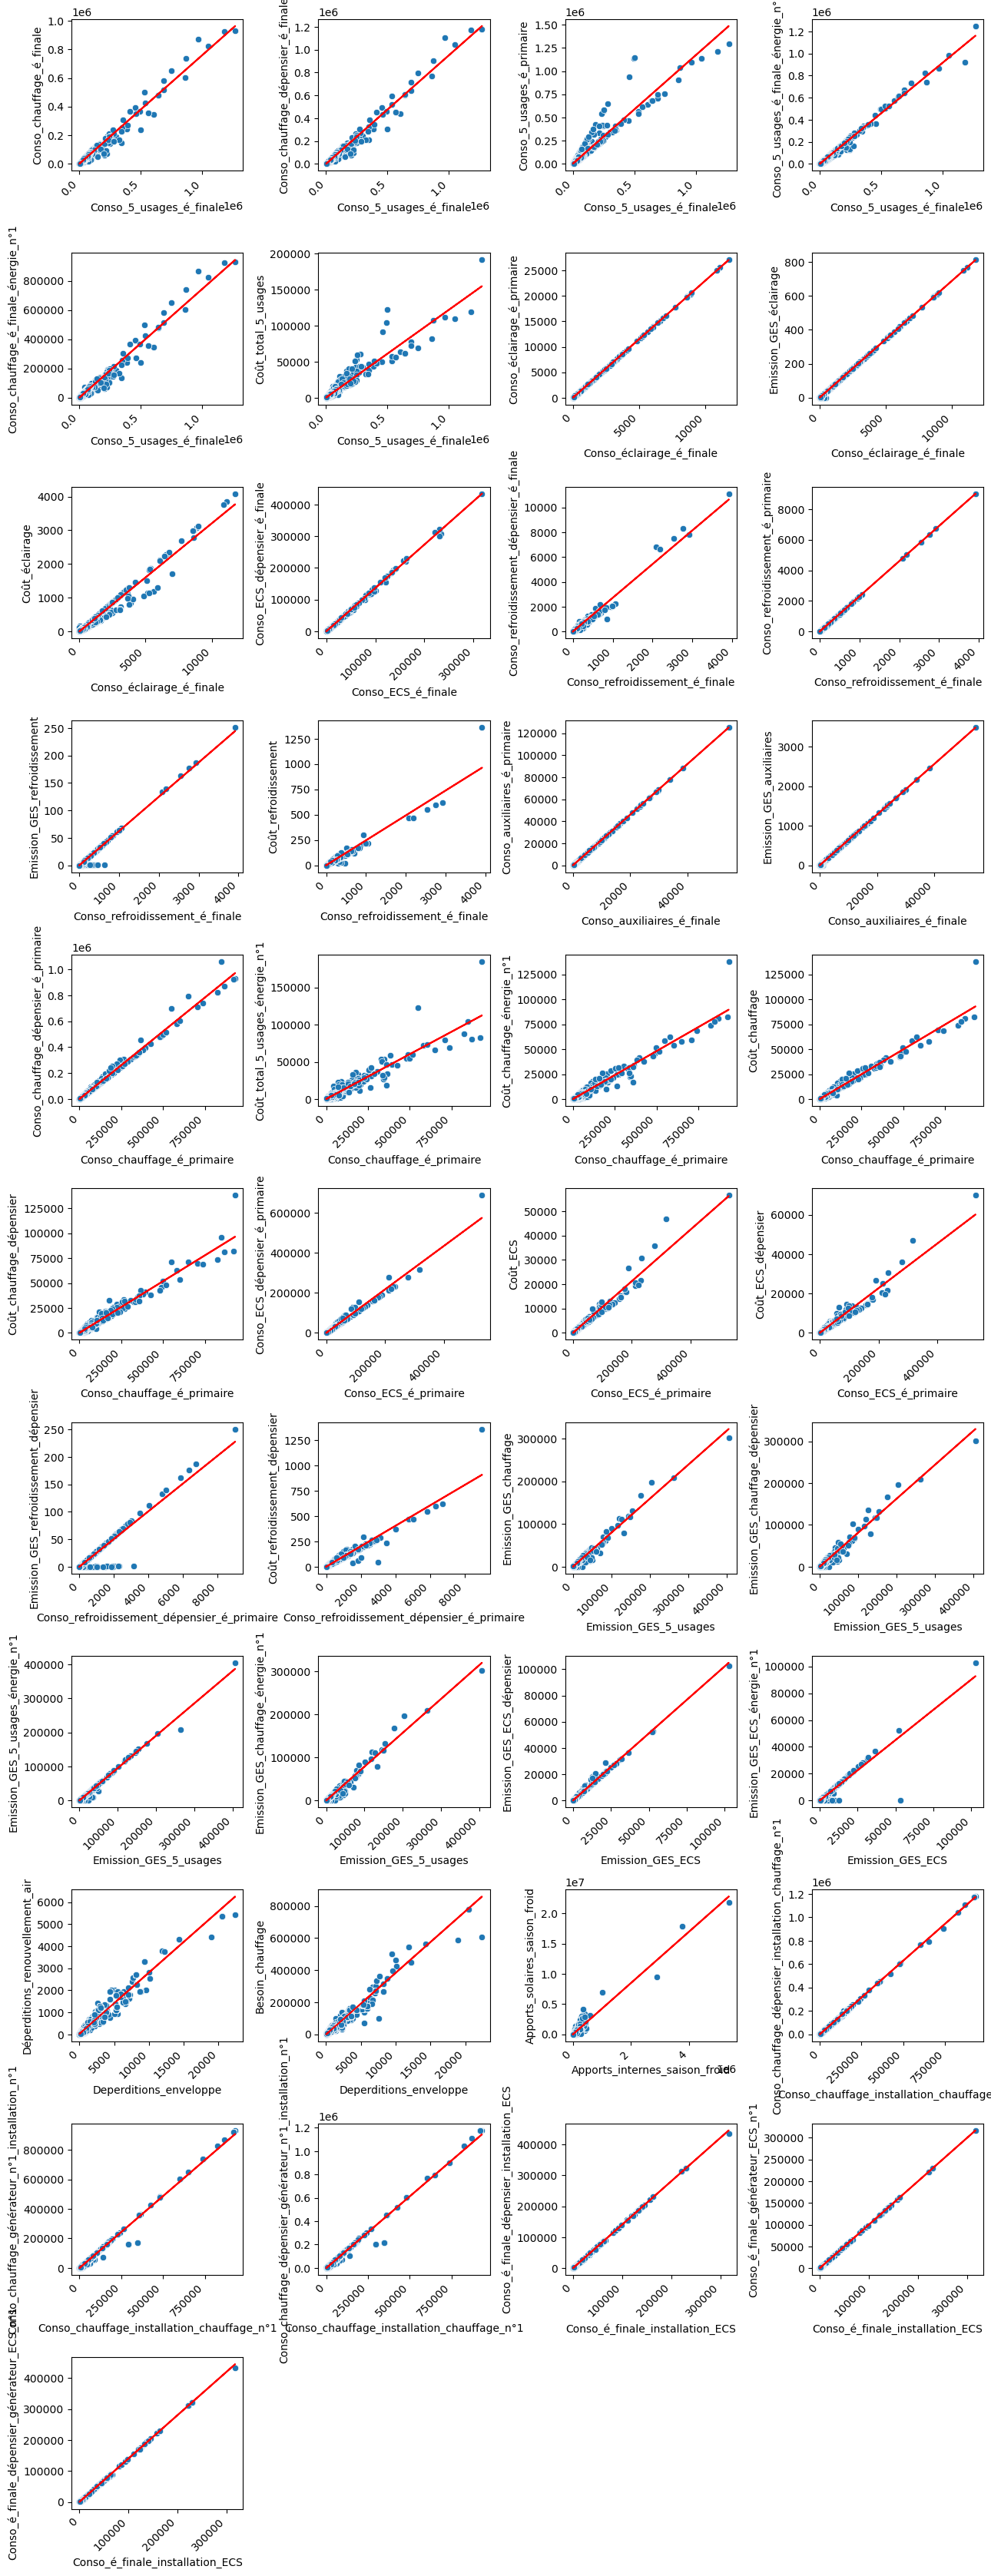

In [253]:
nb_line = (len(df_quant_col) + 3) // 4


plt.figure(figsize=(13, 3 * nb_line))

for i, row in df_lin_regression.iterrows():
    ypred = [row['a'] + row['b']*x for x  in df_quant[row['x']].values]
    plt.subplot(nb_line, 4, i + 1)  # Créer un subplot
    sns.scatterplot(data=df_quant, x=row['x'], y = row['y'])
    plt.plot(df_quant[row['x']].values, ypred, 'r-')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()  
plt.show()


Les résultats précédents sont confirmés par l’analyse visuelle.
La heatmap met en évidence des blocs de variables fortement corrélées, notamment pour les variables de consommation énergétique et d’émissions, ce qui confirme la présence de redondance dans les données.
Les nuages de points associés aux régressions montrent également que les relations sont bien linéaires, avec des points très alignés autour de la droite. Cela valide donc les valeurs élevées de \$R^2$ observées précédemment.

Nous pouvons donc conclure que certaines variables décrivent la même information, en particulier celles liées aux consommations globales et leurs composantes.

Nous allons maintenant poursuivre l’analyse en réalisant une ACP selon deux approches : la première en conservant toutes les variables, et la seconde après avoir supprimé les variables fortement corrélées. Ensuite, à partir des données projetées dans ces deux espaces, nous entraînerons un modèle de classification dans le but de prédire l’étiquette DPE (Diagnostic de Performance Énergétique). Cela nous permettra d’évaluer l’impact de la réduction de redondance sur la performance du modèle.

# ACP

On passe maintenant à l’Analyse en Composantes Principales (ACP). Cette méthode va nous permettre de résumer l’information contenue dans un grand nombre de variables quantitatives, tout en conservant l’essentiel de la variabilité du jeu de données.

Autrement dit, l’idée est de simplifier la lecture des données sans perdre ce qu’elles racontent de plus important. Cette étape est particulièrement utile ici, car plusieurs variables restent corrélées entre elles malgré le nettoyage effectué auparavant.

## Comparaison de deux ACP

Pour mieux comprendre l’effet de la réduction de redondance entre les variables, j’ai choisi de réaliser deux ACP.

La première est effectuée sur l’ensemble des variables quantitatives conservées après le nettoyage.  
La seconde est réalisée après suppression des variables les plus redondantes, à partir des résultats obtenus avec les régressions linéaires.

L’objectif est de voir si le fait d’alléger le jeu de données améliore la lisibilité de l’ACP, la qualité des représentations et l’interprétation globale des axes.

In [261]:
# ============================================================
# ACP 1 : toutes les variables
# ============================================================

X1 = df_quant.values
res_acp1 = acp(X1)

val_p1 = res_acp1["val_p"]
inertie1 = res_acp1["inertie"]

# ============================================================
# ACP 2 : variables réduites
# ============================================================

X2 = df_quant[df_quant_col].values
res_acp2 = acp(X2)

val_p2 = res_acp2["val_p"]
inertie2 = res_acp2["inertie"]

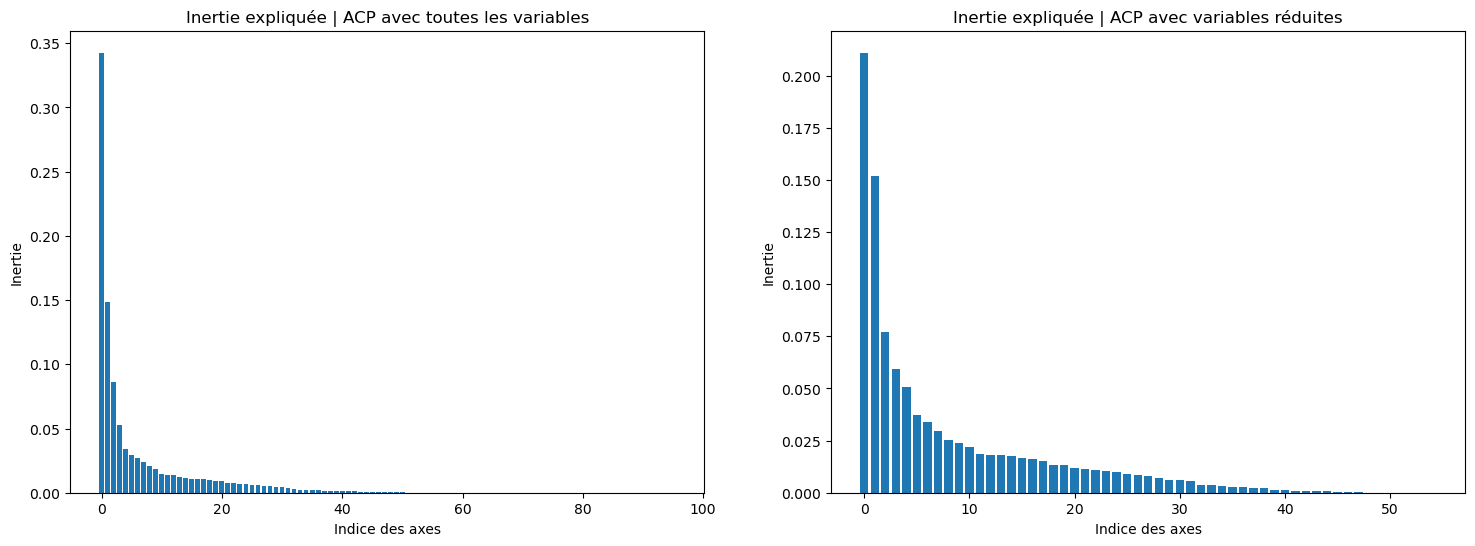

In [262]:
# afichge iinertie expliquer 
plt.figure(figsize=(18,6))

# ACP 1
plt.subplot(121)
plt.bar(x=range(len(val_p1)), height=inertie1)
plt.title("Inertie expliquée | ACP avec toutes les variables")
plt.xlabel("Indice des axes")
plt.ylabel("Inertie")

# ACP 2
plt.subplot(122)
plt.bar(x=range(len(val_p2)), height=inertie2)
plt.title("Inertie expliquée | ACP avec variables réduites")
plt.xlabel("Indice des axes")
plt.ylabel("Inertie")

plt.show()

**1. ACP réalisée en utilisant toutes les variables.**  
Ces résultats suggèrent que l’inertie est très concentrée sur les premiers axes, notamment le premier qui explique une grande partie de la variance. Cela traduit une forte redondance entre les variables, en particulier celles liées aux consommations énergétiques.

**2. ACP réalisée sans les variables fortement corrélées.**  
L’inertie est davantage répartie entre les axes. La structure des données est plus équilibrée, ce qui indique que la redondance a été réduite et que chaque variable apporte une information plus complémentaire.

On peut désormais tracer l’inertie cumulée afin de déterminer le nombre d’axes nécessaires pour expliquer environ 90% de la variabilité

In [263]:
# Calcul de l'inertie cumulée
inertie_cumulee1 = res_acp1["inertie_cumulee"]
inertie_cumulee2 = res_acp2["inertie_cumulee"]

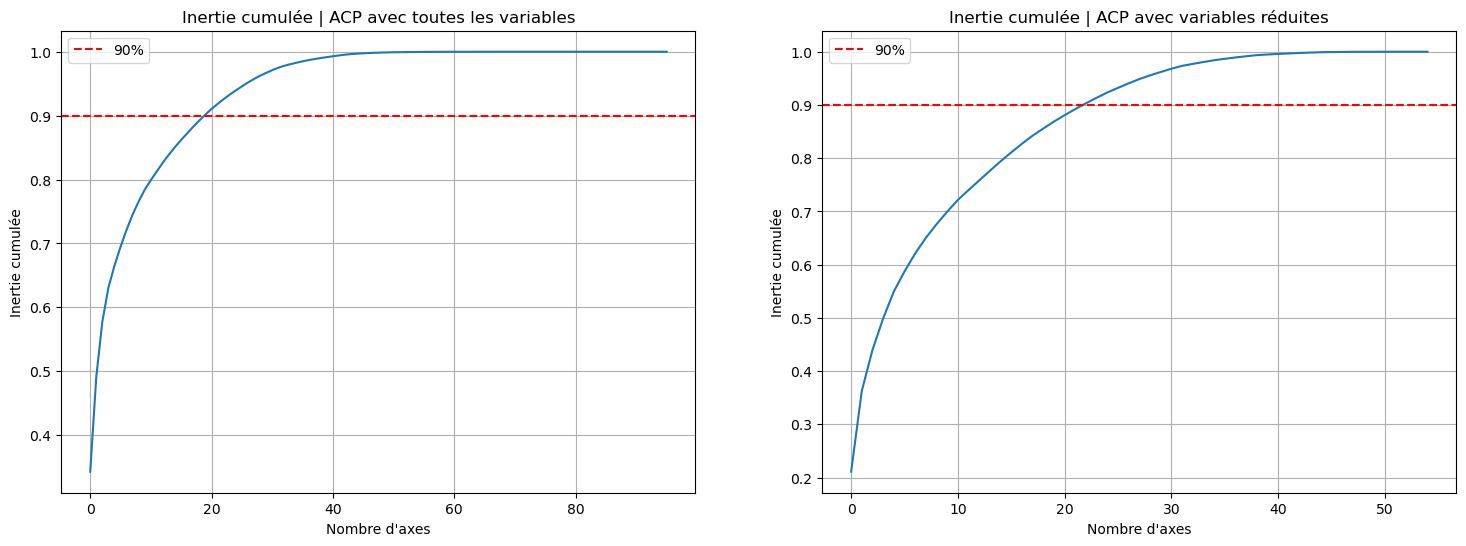

Nombre de composantes nécessaires (ACP 1) : 20
Nombre de composantes nécessaires (ACP 2) : 23


In [268]:
plt.figure(figsize=(18,6))

# ACP 1
plt.subplot(121)
plt.plot(range(len(inertie_cumulee1)), inertie_cumulee1)
plt.axhline(0.9, color='red', linestyle='--', label='90%')
plt.grid()
plt.title("Inertie cumulée | ACP avec toutes les variables")
plt.xlabel("Nombre d'axes")
plt.ylabel("Inertie cumulée")
plt.legend()

# ACP 2
plt.subplot(122)
plt.plot(range(len(inertie_cumulee2)), inertie_cumulee2)
plt.axhline(0.9, color='red', linestyle='--', label='90%')
plt.grid()
plt.title("Inertie cumulée | ACP avec variables réduites")
plt.xlabel("Nombre d'axes")
plt.ylabel("Inertie cumulée")
plt.legend()

plt.show()

# Nombre d'axes nécessaires
print("Nombre de composantes nécessaires (ACP 1) :", (inertie_cumulee1 < 0.9).sum() + 1)
print("Nombre de composantes nécessaires (ACP 2) :", (inertie_cumulee2 < 0.9).sum() + 1)

Le graphique de l’ACP utilisant toutes les variables montre qu’il faut environ 20 composantes pour expliquer 90% de la variance. La croissance est très rapide sur les premiers axes.
En revanche, l’ACP réalisée après suppression des variables fortement corrélées nécessite environ 23 composantes pour atteindre ce même seuil.
Dans les deux cas, l’inertie augmente rapidement sur les premières composantes avant de se stabiliser.
Cependant, l’utilisation de toutes les variables permet d’atteindre le seuil de 90% plus rapidement. Cela s’explique par la présence de redondance entre variables, qui concentre l’information sur un nombre plus réduit d’axes.
À l’inverse, après réduction des variables corrélées, l’information est mieux répartie, ce qui nécessite légèrement plus de composantes pour atteindre le même niveau de variance expliquée.

Nous allons maintenant nous concentrer sur les deux premières composantes principales, afin de projeter les individus dans un plan factoriel et analyser leur répartition.
Nous évaluerons également la qualité de leur représentation dans ce plan, afin de vérifier si ces deux axes suffisent à bien résumer l’information.

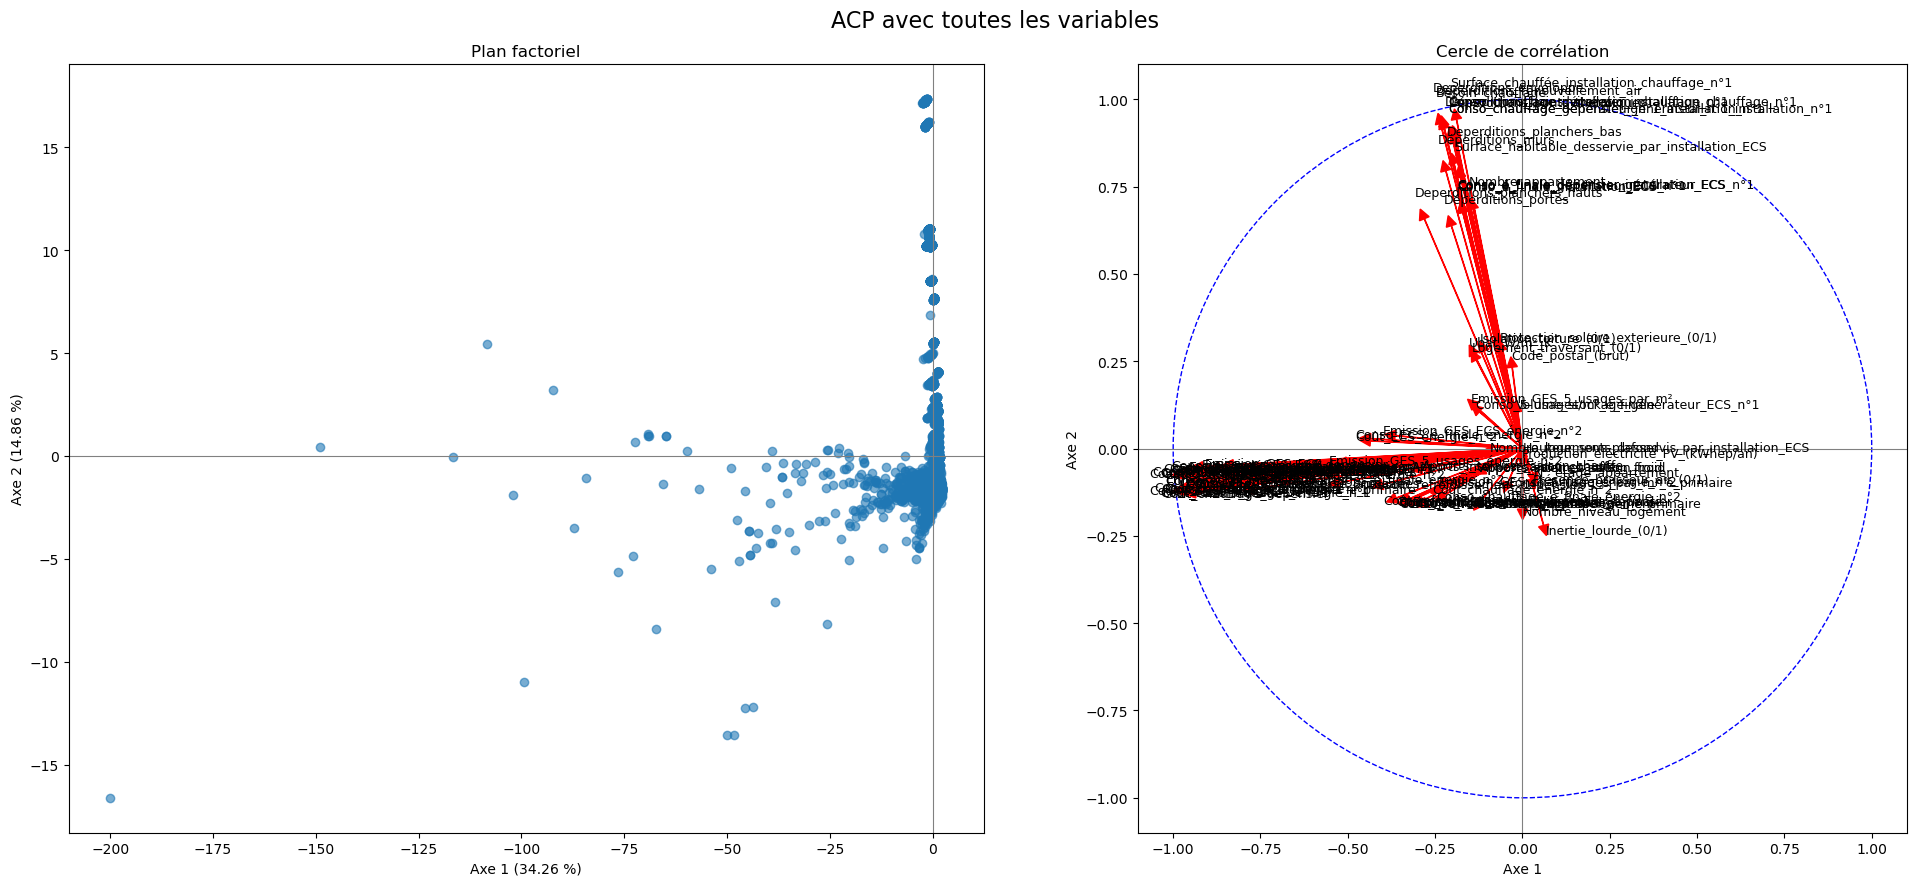

In [271]:
# Récupération des résultats ACP 1
from matplotlib.patches import Circle
X1_proj = res_acp1["proj"]
val_p1 = res_acp1["val_p"]
vec_p1 = res_acp1["vec_p"]

fig, axs = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("ACP avec toutes les variables", fontsize=16)

# Plan factoriel
plot_plan_fact(X1_proj, inertie1, ax=axs[0])

# Cercle de corrélation
cercle_corr(val_p1, vec_p1, list_col=df_quant.columns, ax=axs[1])

plt.tight_layout()
plt.show()

Le plan factoriel montre que la majorité des individus est fortement concentrée, avec quelques observations très éloignées, ce qui traduit la présence de valeurs extrêmes.\
Le cercle de corrélation met en évidence que de nombreuses variables sont fortement corrélées et orientées dans des directions proches, notamment les variables liées aux consommations énergétiques.\
Cela confirme une forte redondance entre variables, déjà observée précédemment, et explique pourquoi une grande partie de l’information est portée par les premiers axes.

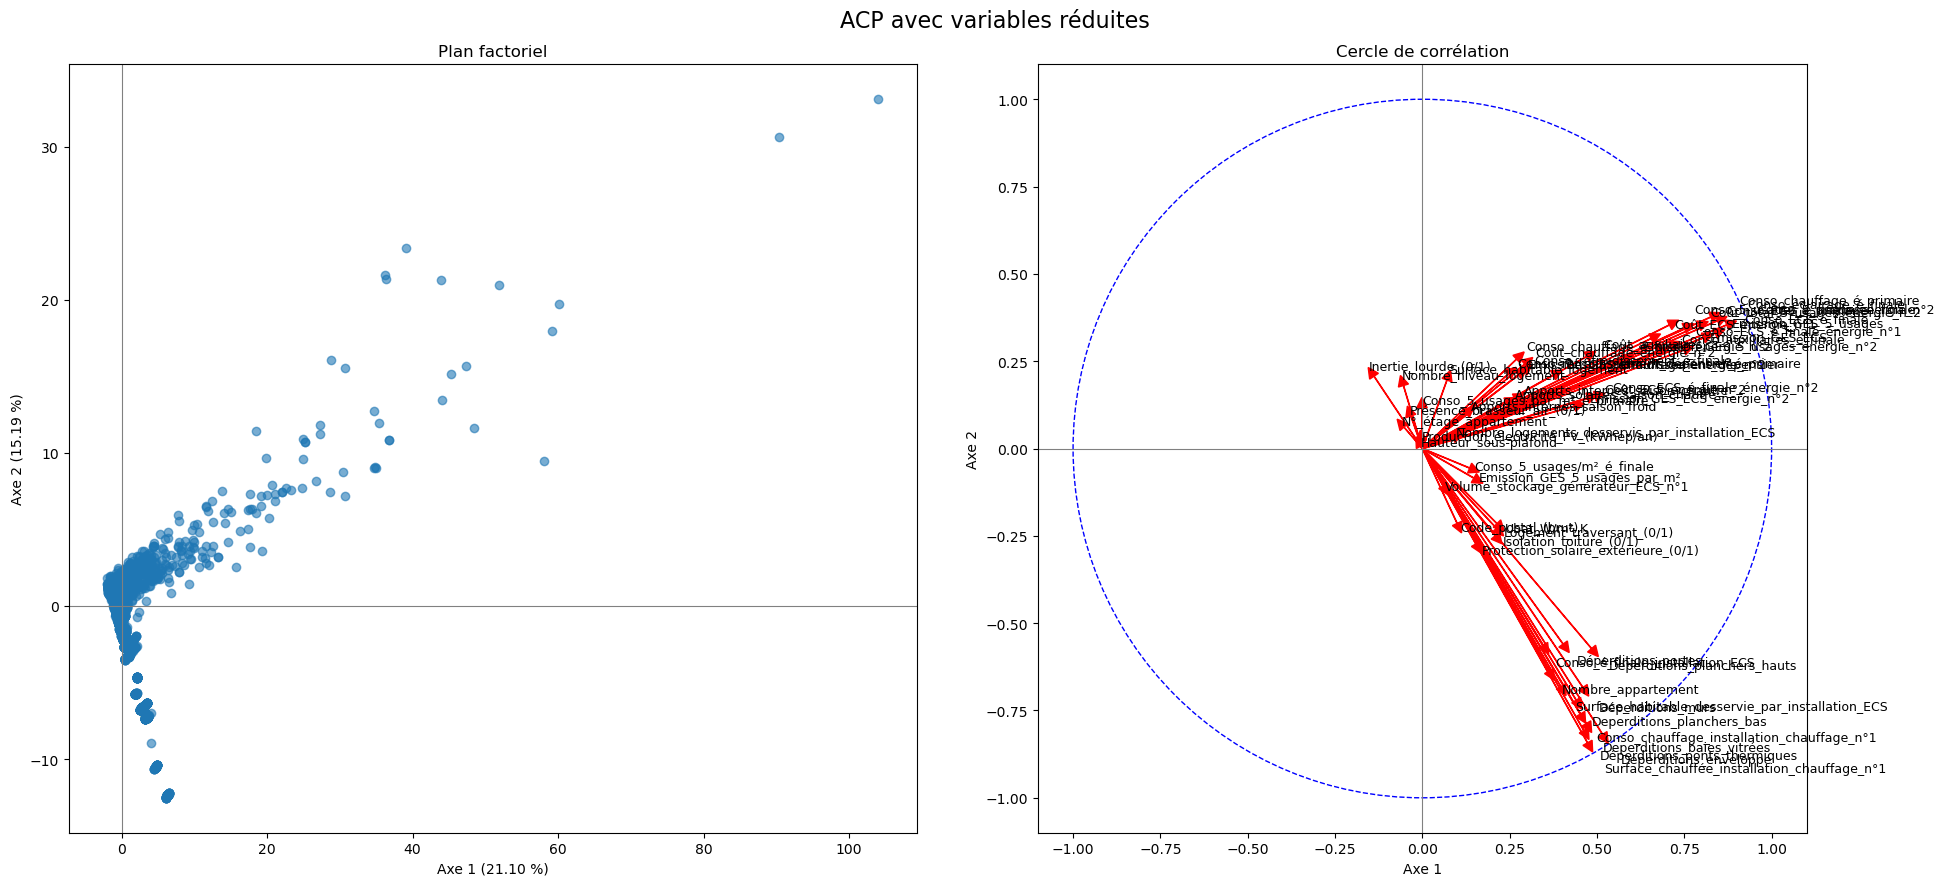

In [272]:
X2_proj = res_acp2["proj"]
val_p2 = res_acp2["val_p"]
vec_p2 = res_acp2["vec_p"]
# Représentation ACP 2 (variables réduites)

fig, axs = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("ACP avec variables réduites", fontsize=16)

plot_plan_fact(X2_proj, inertie2, ax=axs[0])
cercle_corr(val_p2, vec_p2, list_col=df_quant_col, ax=axs[1])

plt.tight_layout()
plt.show()

Sur le nuage de points, On constate toujours une concentration importante d’individus proches de l’origine, ce qui traduit des profils similaires et proches de la moyenne. Cependant, la dispersion est plus marquée que précédemment, avec des individus qui s’éloignent davantage, ce qui rend la structure des données plus lisible.\
On distingue également quelques individus éloignés, notamment vers la partie supérieure droite, indiquant des profils atypiques ou des valeurs extrêmes.

Sur le cercle de corrélation, les variables sont mieux réparties et moins alignées qu’auparavant, ce qui confirme la réduction de la redondance. Certaines variables sont bien représentées (proches du cercle), tandis que d’autres le sont moins, ce qui montre que toute l’information n’est pas portée uniquement par les deux premiers axes. 
Globalement, les variables influencent plusieurs axes à la fois, ce qui traduit une structure plus équilibrée des données après suppression des variables fortement corrélées.

Nous allons maintenant analyser la qualité de représentation des individus sur les axes factoriels, afin de vérifier si les deux premières composantes résument correctement l’information.

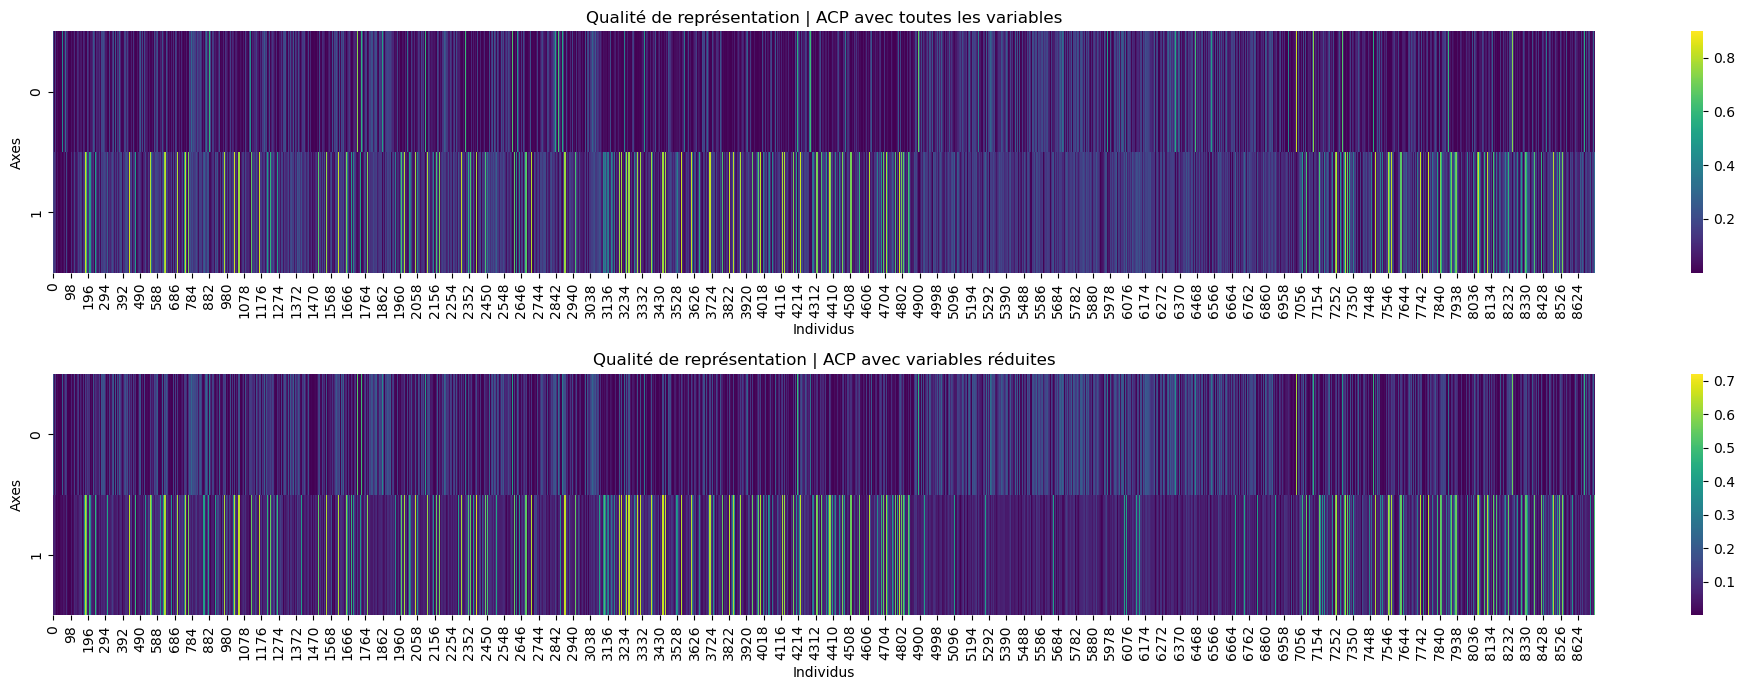

In [273]:
# Calcul du cos² (qualité de représentation)
qualite1 = res_acp1["cos2"][:, :2].T
qualite2 = res_acp2["cos2"][:, :2].T

plt.figure(figsize=(20, 7))

# ACP 1
plt.subplot(211)
sns.heatmap(qualite1, cmap="viridis")
plt.title("Qualité de représentation | ACP avec toutes les variables")
plt.xlabel("Individus")
plt.ylabel("Axes")

# ACP 2
plt.subplot(212)
sns.heatmap(qualite2, cmap="viridis")
plt.title("Qualité de représentation | ACP avec variables réduites")
plt.xlabel("Individus")
plt.ylabel("Axes")

plt.tight_layout()
plt.show()

les deux graphique montrent une structure globale similaire : la qualité de représentation des individus sur les deux premiers axes est très variable.

Dans les deux cas, certains individus sont bien représentés (valeurs élevées de cos²), tandis qu’une grande partie présente des valeurs faibles, indiquant que les deux premiers axes ne suffisent pas à bien résumer toute l’information.

L’ACP utilisant toutes les variables semble légèrement mieux représenter certains individus, avec des valeurs de cos² plus élevées. Cependant, cette amélioration reste limitée.

Globalement, ces résultats montrent que, malgré une forte inertie expliquée par les premiers axes, une part importante de l’information est répartie sur d’autres composantes, ce qui limite la qualité de représentation dans le plan factoriel.

Nous allons maintenant analyser la contribution des individus aux axes factoriels, afin d’identifier ceux qui participent le plus à la construction du plan.

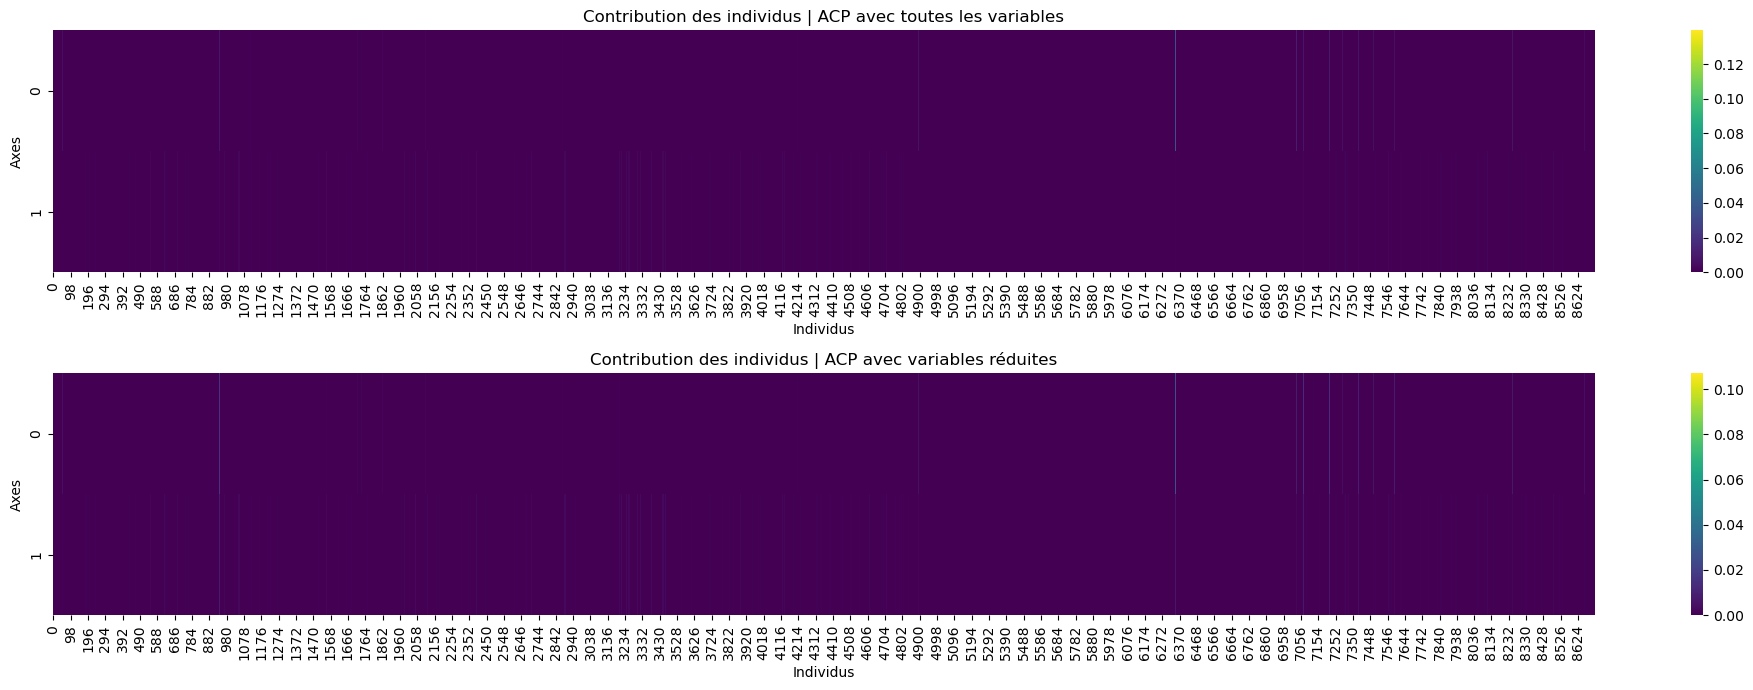

In [274]:
# Contribution des individus

contrib1 = res_acp1["contrib"][:, :2].T
contrib2 = res_acp2["contrib"][:, :2].T

plt.figure(figsize=(20, 7))

# ACP 1
plt.subplot(211)
sns.heatmap(contrib1, cmap="viridis")
plt.title("Contribution des individus | ACP avec toutes les variables")
plt.xlabel("Individus")
plt.ylabel("Axes")

# ACP 2
plt.subplot(212)
sns.heatmap(contrib2, cmap="viridis")
plt.title("Contribution des individus | ACP avec variables réduites")
plt.xlabel("Individus")
plt.ylabel("Axes")

plt.tight_layout()
plt.show()

On constate encore que les deux graphiques se ressemblent globalement. Dans les deux cas, la majorité des individus a une contribution très faible à la construction des axes.

Seuls quelques individus présentent une contribution plus élevée, ce qui signifie qu’ils influencent davantage la formation des axes factoriels.

Ces individus peuvent être considérés comme atypiques ou plus structurants dans les données, tandis que la plupart des observations ont un impact limité.

La suppression des variables corrélées ne modifie pas fortement cette structure, ce qui confirme que seuls certains individus jouent un rôle important dans l’ACP.

## Bilan ACP 

Dans cette section, nous avons réalisé deux analyses en composantes principales :  
la première sur l’ensemble des variables quantitatives, et la seconde après suppression des variables fortement corrélées (R² > 90%).

Plusieurs éléments ressortent de cette comparaison :

Tout d’abord, en termes d’inertie expliquée, la première ACP permet de concentrer davantage l’information sur un nombre plus réduit de composantes. En effet, environ 20 composantes sont nécessaires pour expliquer 90% de la variabilité dans l’ACP1, contre environ 23 pour l’ACP2. De plus, les deux premières composantes expliquent environ 45% de la variance dans le premier cas, contre seulement 33% dans le second. Cela montre que l’ACP réalisée sur toutes les variables capte plus rapidement l’information, notamment en raison de la redondance entre variables.

Ensuite, l’analyse des cercles de corrélation confirme ces observations. Dans l’ACP1, les variables sont fortement regroupées et bien représentées (vecteurs proches du cercle), ce qui facilite l’interprétation des axes. À l’inverse, dans l’ACP2, les variables sont plus dispersées et certaines sont moins bien représentées, ce qui rend la lecture des axes plus complexe. La suppression des variables corrélées a ainsi atténué la structure initiale des relations entre variables.

Concernant la représentation des individus, les deux ACP montrent que la qualité de projection sur les deux premiers axes est globalement limitée pour une grande partie des observations. Néanmoins, l’ACP1 semble légèrement mieux représenter certains individus, bien que la différence reste modérée.

Enfin, l’analyse des contributions met en évidence que seuls quelques individus influencent réellement la construction des axes, ce qui est cohérent dans les deux approches.

Au final, ces résultats montrent que la suppression des variables fortement corrélées n’apporte pas d’amélioration dans notre cas. Au contraire, elle tend à répartir l’information sur davantage de composantes et à rendre l’interprétation moins claire. Dans le cadre du diagnostic de performance énergétique, conserver l’ensemble des variables permet donc de mieux capturer la structure globale des données.

# Mise en place du clustering

## Détermination du nombre de clusters et mise en place du K-Means

### Clustering

Après avoir projeté les individus dans l’espace ACP, nous cherchons maintenant à identifier des groupes homogènes à l’aide de l’algorithme des k-moyennes (K-Means).

Pour cela, nous utilisons les composantes principales conservant environ 90% de la variabilité, afin de travailler dans un espace de dimension réduite tout en conservant l’essentiel de l’information.

L’algorithme K-Means repose sur la minimisation de l’inertie intra-classes, définie par :

$$
J_{intra} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

où :
- $C_k$ représente le cluster $k$,
- $\mu_k$ est le centre du cluster $k$,
- $x_i$ est un individu appartenant au cluster $C_k$.

Cette quantité mesure la compacité des clusters : plus elle est faible, plus les individus d’un même cluster sont proches entre eux.

En parallèle, on peut également considérer l’inertie inter-classes, définie par :

$$
J_{inter} = \sum_{k=1}^{K} n_k \|\mu_k - \mu\|^2
$$

où :
- $n_k$ est le nombre d’individus dans le cluster $k$,
- $\mu_k$ est le centre du cluster $k$,
- $\mu$ est le centre global du nuage de points.

Cette quantité mesure la séparation entre les clusters : plus elle est élevée, plus les groupes sont distincts.

Nous faisons donc varier le nombre de clusters $K$ afin d’analyser l’évolution de ces deux quantités et identifier une partition pertinente des données.

In [289]:
from sklearn.cluster import KMeans

X = X1_proj[:, :20]  # 90% variabilité
X = normalisation(X)

centre_nuage_point = np.mean(X, axis=0)
inertie_totale = np.sum(np.linalg.norm(X - centre_nuage_point, axis=1)**2)

inertie_intra_cluster = []
inertie_inter_cluster = []

for i in range(1, 9):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X)
    
    inertie_intra_cluster.append(model.inertia_)
    inertie_inter_cluster.append(inertie_totale - model.inertia_)

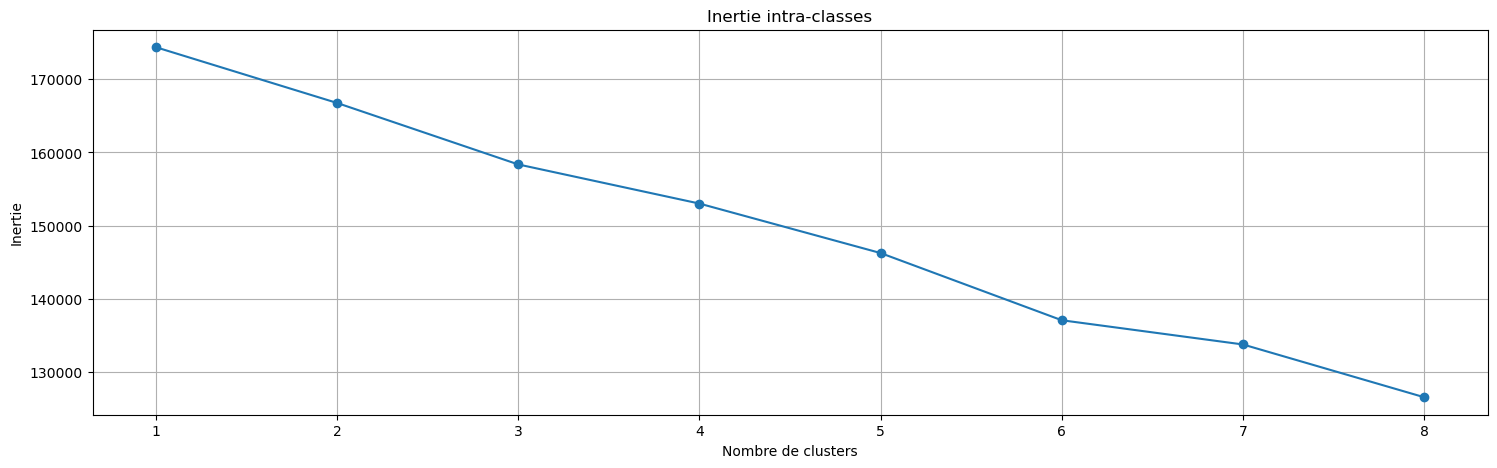

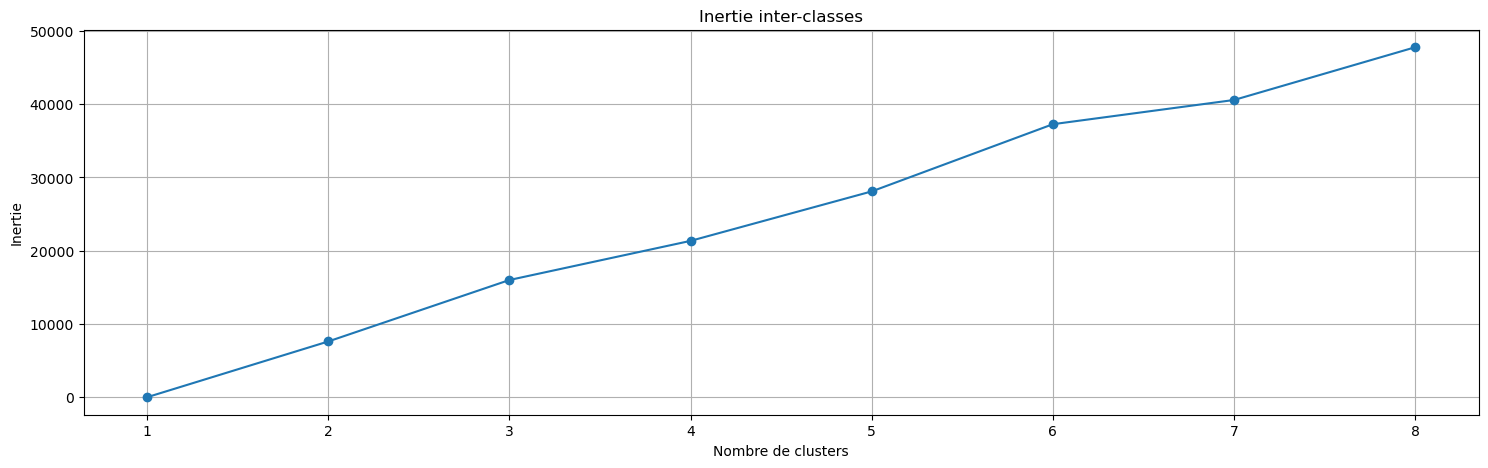

In [290]:
plt.figure(figsize=(18, 5))
plt.plot(range(1, 9), inertie_intra_cluster, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Inertie intra-classes")
plt.grid()
plt.show()

plt.figure(figsize=(18, 5))
plt.plot(range(1, 9), inertie_inter_cluster, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Inertie inter-classes")
plt.grid()
plt.show()

Ces résultats suggèrent que l’inertie intra-classes diminue de manière régulière lorsque le nombre de clusters augmente, tandis que l’inertie inter-classes augmente progressivement.

Cependant, on ne distingue pas de “coude” très marqué sur la courbe de l’inertie intra-classes, ce qui rend le choix du nombre optimal de clusters peu évident.

On peut néanmoins observer un léger changement de pente autour de \(K = 6\), ce qui peut constituer un compromis raisonnable entre compacité des clusters et complexité du modèle.

Au-delà, l’amélioration devient plus progressive, ce qui indique un gain limité à augmenter davantage le nombre de clusters.

Ces résultats sont cohérents avec les observations réalisées lors de l’ACP. En effet, le nuage de points montrait une forte concentration des individus autour de l’origine, avec seulement quelques observations éloignées.

Cela suggère l’absence de groupes bien distincts dans les données, ce qui explique pourquoi la méthode des k-moyennes ne met pas en évidence de structure de clusters clairement séparés.

La présence de quelques individus très éloignés du centre du nuage peut également perturber l’algorithme K-Means, celui-ci étant sensible aux valeurs extrêmes. Ces observations peuvent influencer la position des centres de clusters et rendre la structure globale moins lisible.

Au final, l’absence de coude marqué et la forte concentration des individus observée dans l’ACP suggèrent que les données ne présentent pas de groupes naturellement bien séparés. Le clustering par K-Means ne permet donc pas de dégager une structure claire dans ce cas.

Cela peut s’expliquer à la fois par la nature des données et par la présence de quelques observations atypiques influençant la partition.

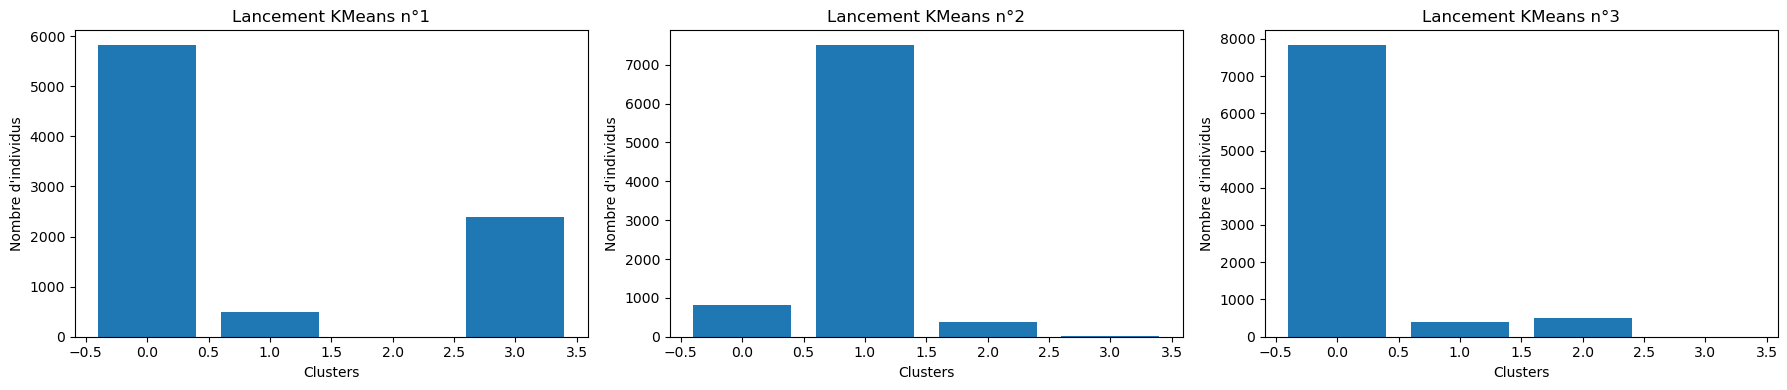

In [291]:
k_model = []

for i in range(3): 
    model = KMeans(n_clusters=4, n_init=10, max_iter=1000)
    model.fit(X)
    
    # récupérer les clusters + leurs tailles
    clusters, counts = np.unique(model.labels_, return_counts=True)
    k_model.append((clusters, counts))


plt.figure(figsize=(18, 4))

for i, val in enumerate(k_model, start=1):
    plt.subplot(1, 3, i)
    plt.bar(x=val[0], height=val[1])
    plt.title(f"Lancement KMeans n°{i}")
    plt.xlabel("Clusters")
    plt.ylabel("Nombre d'individus")

plt.tight_layout()
plt.show()

On observe que la répartition des individus dans les clusters varie fortement d’un lancement à l’autre.

Dans certains cas, un cluster regroupe la grande majorité des individus, tandis que les autres clusters contiennent très peu d’observations. Cette structure change selon les initialisations de l’algorithme.

Cela montre que le clustering par K-Means est instable sur ces données et ne permet pas d’identifier des groupes robustes.

Ces résultats confirment les observations précédentes : les données ne présentent pas de structure de clusters bien définie, mais plutôt une forte concentration d’individus avec quelques observations atypiques.

## Suppression des outliers avec la méthode IQR

In [295]:

# Calcul des quartiles
Q1 = df_nettoye.quantile(0.25)
Q3 = df_nettoye.quantile(0.75)

# Calcul de l'IQR
IQR = Q3 - Q1

# Bornes
lower_bound = Q1 - 2 * IQR
upper_bound = Q3 + 2 * IQR

# Filtrage vectorisé (beaucoup plus rapide)
mask = ~((df_nettoye < lower_bound) | (df_nettoye > upper_bound)).any(axis=1)

df_nettoye_no_outliers = df_nettoye[mask]

print("Shape après suppression des outliers :", df_nettoye_no_outliers.shape)

Shape après suppression des outliers : (983, 106)


Nous constatons que cette approche entraîne une perte très importante de données. En effet, après suppression des observations atypiques, notre dataset passe de plus de 8000 individus à seulement 983, soit une réduction drastique de la taille de l’échantillon.
Une telle perte peut poser plusieurs problèmes. D’une part, elle réduit fortement la représentativité des données, en éliminant potentiellement des profils intéressants. D’autre part, elle peut biaiser les analyses en ne conservant qu’une partie très spécifique de la population.
Ainsi, bien que la suppression des outliers puisse améliorer localement certains résultats, elle apparaît ici trop coûteuse en termes d’information. Cette méthode ne semble donc pas adaptée dans notre cas.

Face à l’instabilité du clustering, notamment avec l’algorithme K-Means, et à l’impact important des outliers sur les résultats, nous choisissons de ne pas poursuivre cette approche.
En effet, les groupes obtenus ne sont ni stables ni interprétables, ce qui limite fortement leur intérêt dans le cadre de notre étude.
Nous décidons donc d’orienter notre démarche vers une approche prédictive. Plus précisément, nous allons utiliser un modèle de type Random Forest afin de prédire directement l’étiquette DPE.
Ce choix présente plusieurs avantages : ce type de modèle est robuste aux valeurs atypiques et permet également d’identifier les variables les plus importantes dans la prédiction. Cela nous permettra de mieux comprendre les facteurs influençant le diagnostic de performance énergétique, ainsi que les seuils associés.

## Prédiction DPE avec Random Forest

In [297]:
# On utilise les composantes principales expliquant environ 90% de la variabilité
X = normalisation(X1_proj[:, :20])

# Variable cible
y = df_nettoye['Etiquette_DPE'].values

# Séparation apprentissage / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Création du modèle Random Forest
model = RandomForestClassifier(n_estimators=200, random_state=42)

# Entraînement
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [298]:
# Prédiction sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluation du modèle
print("Accuracy :", accuracy_score(y_test, y_pred))
print(" Rapport de classification :")
print(classification_report(y_test, y_pred))

Accuracy : 0.8274082568807339
 Rapport de classification :
              precision    recall  f1-score   support

           0       0.89      0.69      0.78        78
           1       0.75      0.66      0.70       165
           2       0.78      0.77      0.78       329
           3       0.83      0.89      0.86       585
           4       0.86      0.91      0.89       500
           5       0.88      0.50      0.64        56
           6       0.92      0.74      0.82        31

    accuracy                           0.83      1744
   macro avg       0.84      0.74      0.78      1744
weighted avg       0.83      0.83      0.82      1744



Le modèle Random Forest atteint une accuracy globale de 0.83%, ce qui témoigne d’une performance satisfaisante et d’une bonne capacité à généraliser sur les données de test.

Cela signifie qu’environ 83% des prédictions du modèle sont correctes, ce qui est encourageant compte tenu de la complexité des données et de la présence de classes déséquilibrées.

En analysant plus en détail le rapport de classification, on observe que les classes les plus représentées, comme les classes 3 et 4, sont bien reconnues par le modèle, avec des scores F1 élevés (respectivement 0.86 et 0.89).

La classe 4, notamment, est très bien prédite avec un recall de 0.91, ce qui montre que le modèle identifie correctement la majorité des individus appartenant à cette classe.

En revanche, pour certaines classes moins bien représentées ou plus difficiles à distinguer, comme la classe 5, le recall est plus faible (0.50), ce qui indique que le modèle a des difficultés à détecter tous les individus de cette catégorie.

De manière générale, le résultata met en évidence que les performances varient selon les classes, ce qui peut s’expliquer par un déséquilibre dans les données ainsi que par des similitudes entre certaines catégories de DPE.

Néanmoins, les résultats globaux restent satisfaisants, comme en témoigne l’accuracy et le score F1 pondéré (0.82), ce qui montre que le modèle parvient globalement à bien prédire les étiquettes DPE.

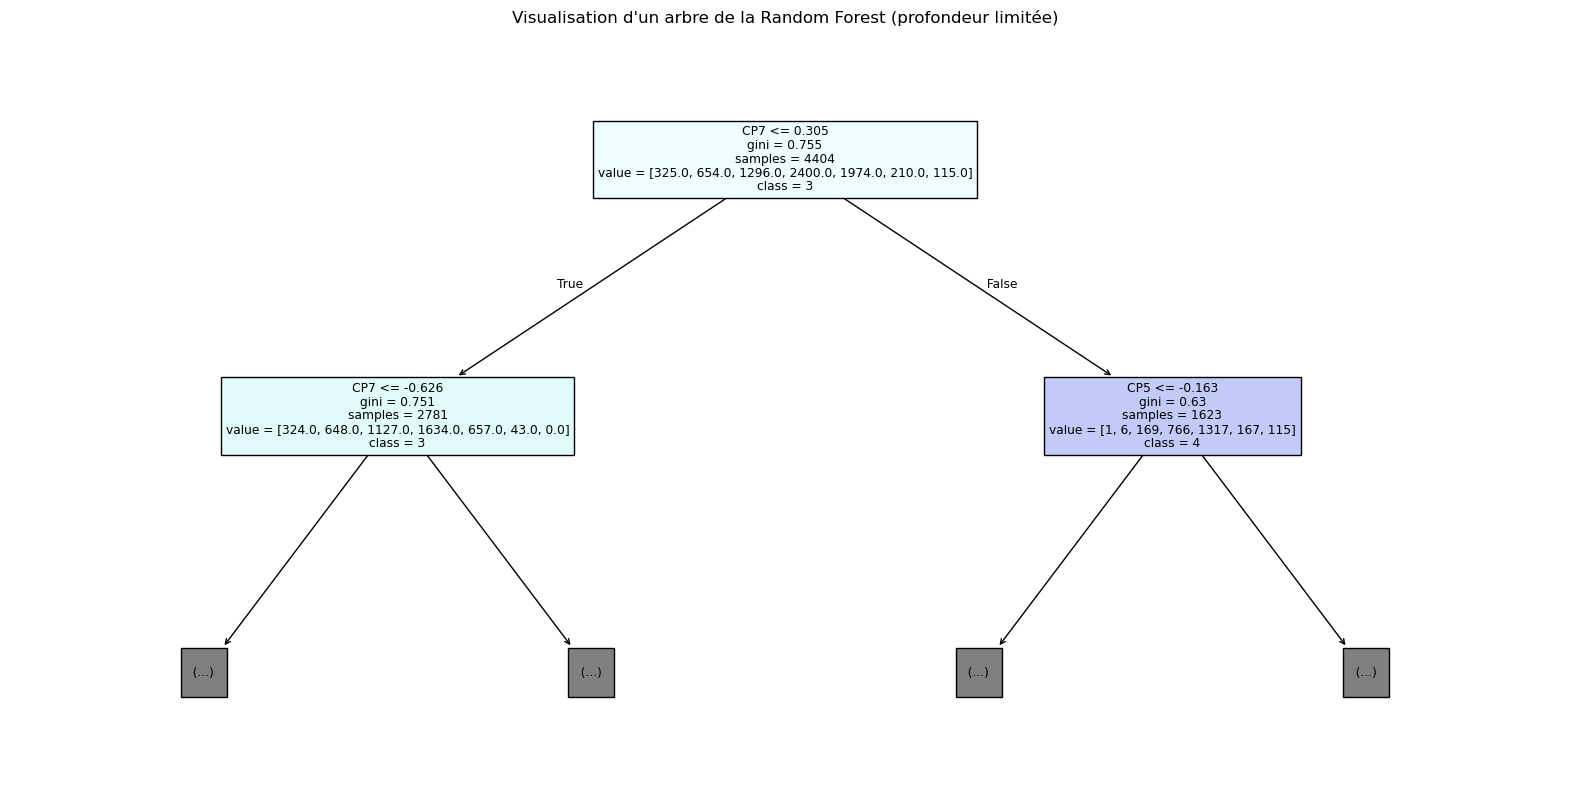

In [299]:
plt.figure(figsize=(20, 10))

plot_tree(
    model.estimators_[0],
    filled=True,
    feature_names=[f"CP{i}" for i in range(1, 21)],
    class_names=[str(i) for i in np.unique(y)],
    max_depth=1
)

plt.title("Visualisation d'un arbre de la Random Forest (profondeur limitée)")
plt.show()

Le graphique montre que la classification repose sur des règles simples basées sur les composantes principales. Par exemple, la première séparation se fait sur la composante CP7, ce qui montre qu’elle joue un rôle important dans la distinction des classes.
Ensuite, d’autres composantes comme CP5 interviennent pour affiner la classification. Chaque nœud correspond à une condition qui permet de répartir les individus en fonction de leurs caractéristiques.
Bien que cet arbre soit volontairement simplifié (profondeur limitée), il illustre le fonctionnement global du modèle : une succession de règles permettant de segmenter progressivement les données.
La Random Forest combine un grand nombre de ces arbres, ce qui permet d’obtenir une prédiction plus robuste et plus précise.

# Conclusion

Au terme de cette étude, plusieurs enseignements importants peuvent être retenus.
### Phase de nettoyage
Nous avons défini des critères de nettoyage adaptés à nos besoins, notamment la suppression des colonnes comportant plus de 80% de valeurs manquantes, ainsi que des variables qualitatives non ordinales.  
Pour le traitement des valeurs manquantes, nous avons choisi d’utiliser la médiane pour les variables quantitatives, en raison de la présence d’outliers (la moyenne étant souvent supérieure à la médiane), et le mode pour les variables qualitatives.

Cette phase a pu introduire certains biais, notamment en raison de colonnes très incomplètes. Nous avons également transformé les variables qualitatives en variables exploitables pour nos analyses.  
Ainsi, nous sommes passés d’un dataset initial de dimension 8718 × 242 à un dataset nettoyé de 8718 × 111.


### Phase de régression
Nous avons réalisé des régressions linéaires deux à deux afin de détecter et supprimer les variables fortement corrélées.  
En fixant un seuil de \(R^2 > 0.90\), nous avons éliminé les variables redondantes. Cette étape nous a permis de réduire le nombre de variables de 111 à 67.


### Phase ACP
Nous avons ensuite réalisé deux analyses en composantes principales (ACP) :

- une ACP sur l’ensemble des données nettoyées (ACP1),
- une ACP après suppression des variables fortement corrélées (ACP2).

Les résultats montrent que l’ACP1 est plus performante :

- 90% de la variabilité expliquée avec environ **20 composantes** (contre 23 pour ACP2),
- environ **45% de variance expliquée** par les deux premiers axes (contre 33% pour ACP2).

Les cercles de corrélation montrent que l’ACP1 conserve une structure claire avec des variables bien représentées, tandis que l’ACP2 présente une information plus dispersée et moins interprétable.

Concernant les individus, la qualité de représentation reste globalement limitée sur les deux premiers axes dans les deux cas, mais l’ACP1 reste légèrement plus performante.

Nous concluons donc que la suppression des variables corrélées, bien que théoriquement pertinente, s’avère ici contre-productive.


### Phase de classification
Nous avons d’abord exploré une approche de clustering avec l’algorithme K-Means.  
Cependant, l’analyse des inerties n’a pas révélé de structure de clusters claire, et les résultats se sont montrés instables selon les initialisations.

Le nuage de points issu de l’ACP montrait déjà une forte concentration des individus, avec quelques valeurs atypiques, ce qui explique l’absence de groupes bien distincts.

La suppression des outliers a entraîné une perte massive de données (réduction à 983 individus), rendant cette approche non viable.

Nous avons donc choisi d’abandonner le clustering au profit d’un modèle supervisé : la Random Forest.

Ce modèle a atteint une accuracy de **83%**, avec de bonnes performances sur les classes les plus représentées (notamment les classes intermédiaires).  
Les classes moins fréquentes restent plus difficiles à prédire, en raison du déséquilibre des données.

Enfin, l’analyse des arbres permet d’illustrer les règles de décision, même si l’interprétation reste globale du fait de la nature ensemble du modèle.


### Bilan général
Ce projet montre l’importance :

- de la qualité des données,
- du choix des méthodes adaptées,
- et de l’interprétation des résultats.

Toutes les approches ne sont pas pertinentes dans tous les contextes, et il est essentiel d’adapter sa démarche en fonction des observations.

### Retour personnel
D’un point de vue personnel, j’ai particulièrement apprécié ce projet. Il m’a permis d’explorer différentes méthodes, de tester des hypothèses, et d’ajuster mes choix en fonction des résultats obtenus.

Ce projet m’a également sensibilisé à l’importance de la phase de préparation des données, souvent sous-estimée, mais pourtant essentielle pour obtenir des résultats fiables.

Au-delà de l’aspect technique, il m’a permis de développer une réflexion critique sur les méthodes utilisées, ce qui constitue un élément clé en data science.